## Reading in a short story as text sample into Python.

### Step 1: Creating Tokens

In [1]:
%config Completer.use_jedi = False

In [2]:
# Reading the file
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of character:", len(raw_text))
print(raw_text[:99]) # The print command prints the total number of characters followed by the first 100 characters of this file for illustration purposes.

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


### Our goal is to tokenize this 20,479-character short story into individual words and special characters that we can then turn into embeddings for LLM training

### Note that it's common to process millions of articles and hundreds of thousands of
### books -- many gigabytes of text -- when working with LLMs. However, for educational
### purposes, it's sufficient to work with smaller text samples like a single book to
### illustrate the main ideas behind the text processing steps and to make it possible to
### run it in reasonable time on consumer hardware.

### How can we best split this text to obtain a list of tokens? For this, we go on a small
### excursion and use Python's regular expression library re for illustration purposes.

In [3]:
import re # re means regular expression

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

# What re.split(r'(\s)', text) does
# \s → matches any whitespace (space, tab, newline).
# () → capturing group.
# When used in re.split, the delimiter is also returned in the result list.
# So the string is split at every whitespace, but the whitespace itself is kept in the output.

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [4]:
### The result is a list of individual words, whitespaces, and punctuation characters. We can't stop over here because i want punctuations to be in a separate
### token becuause I want my LLM to know which are punctuations and which are normal words, so I want comma to be a separate token and full stop to be a 
### separate token.

In [5]:
# Let's modify the regular expression splits on whitespaces (\s) and commas, and periods ([,.]):

In [6]:
result = re.split(r'([,.]|\s)', text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [7]:
# We can see that the words and punctuation characters are now separate list entries just as we wanted.
# A small remaining issue is that the list still includes whitespace characters. Optionally, we can remove these redundant characters,

In [8]:
result = [item for item in result if item.strip()] # Loop and return the item only if item.strip() returns true. So whitwspaces won't be returned.

print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [9]:
# REMOVING WHITESPACES OR NOT

# When developing a simple tokenizer, whether we should encode whitespaces as separate characters or just remove them depends on our application 
# and its requirements. Removing whitespaces reduces the memory and computing requirements. However, keeping whitespaces can be useful if we train 
# models that are sensitive to the exact structure of the text (for example, Python code, which is sensitive to indentation and spacing). Here, we 
# remove whitespaces for simplicity and brevity of the tokenized outputs. Later, we will switch to a tokenization scheme that includes whitespaces.

In [10]:
# The tokenization scheme we devised above works well on the simple sample text. Let's modify it a bit further so that it can also handle other types 
# of punctuation, such as question marks, quotation marks, and the double-dashes we have seen earlier in the first 100 characters of Edith Wharton's 
# short story, along with additional special characters:

In [11]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [12]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [13]:
print(len(preprocessed))

4690


In [14]:
### In the 4690 tokens there may be duplications also because we have not got rid of duplications here.
### We now need numberical representations because computers don't understand words.

In [15]:
# Creating Token IDs

# In the previous section, we tokenized Edith Wharton's short story and assigned it to a Python variable called preprocessed. Let's now create 
# a list of all unique tokens and sort them alphabetically to determine the vocabulary size.

# Vocabulary is just a list of tokens which is sorted in alphabetical manner and then each unique token is mapped to a unique integer which is called as token id.

In [16]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1130


In [17]:
# After determining that the vocabulary size is 1,130 via the above code, we create the vocabulary and print its first 51 entries for illustration purposes.

In [18]:
vocab = {token:integer for integer,token in enumerate(all_words)}

In [19]:
for i,item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [20]:
# As we can see, based on the output above, the dictionary contains individual tokens associated with unique integer labels.

# Later in this book, when we want to convert the outputs of an LLM from numbers back into text, we also need a way to turn token IDs into text.
# For this, we can create an inverse version of the vocabulary that maps token IDs back to corresponding text tokens.

# Let's implement a complete tokenizer class in Python.
# The class will have an encode method that splits text into tokens and carries out the string-to-integer mapping to produce token IDs via the vocabulary.
# In addition, we implement a decode method that carries out the reverse integer-to-string mapping to convert the token IDs back into text.

# Step 1: Store the vocabulary as a class attribute for access in the encode and decode methods
# Step 2: Create an inverse vocabulary that maps token IDs back to the original text tokens
# Step 3: Process input text into token IDs
# Step 4: Convert token IDs back into text
# Step 5: Replace spaces before the specified punctuation


In [21]:
class SimpleTokenizerV1:

    # __init__ method is called by default when a instance of SimpleTokenizerV1 is created
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        # print(preprocessed)
        ids = [self.str_to_int[s] for s in preprocessed]

        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations.lets suppose the joined tokens came out to be "Fox is chased ." So the problem is that
        # there is a space between . and chased. So below operation will output "Fox is chased."
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [22]:
# Let's instantiate a new tokenizer object from the SimpleTokenizerV1 class and tokenize a passage from Edith Wharton's short story to try 
# it out.

In [23]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," 
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [24]:
# The code above prints the following token IDs:
# Next, let's see if we can turn these token IDs back into text using the decode method:

In [25]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [26]:
# Based on the output above, we can see that the decode method successfully converted the token IDs back into the original text.

In [27]:
# Let's now apply it to a new text sample that is not contained in the training set. Meaning what if some words are not present in vocabulary.

In [28]:
text = "Hello, do you like tea?"
print(tokenizer.encode(text))
# The problem is that the word "Hello" was not used in the The Verdict short story.Hence, it is not contained in the vocabulary. 
# This highlights the need to consider large and diverse training sets to extend the vocabulary when working on LLMs.

KeyError: 'Hello'

In [29]:
# The problem is that the word "Hello" was not used in the The Verdict short story.
# Hence, it is not contained in the vocabulary.
# This highlights the need to consider large and diverse training sets to extend the vocabulary when working on LLMs.

In [30]:
# ADDING SPECIAL CONTEXT TOKENS
# In the previous section, we implemented a simple tokenizer and applied it to a passage from the training set.
# In this section, we will modify this tokenizer to handle unknown words.
# In particular, we will modify the vocabulary and tokenizer we implemented in the previous section, SimpleTokenizerV2, to support two new tokens, <|unk|> 
# and <|endoftext|>

In [31]:
# We can modify the tokenizer to use an <|unk|> token if it encounters a word that is not part of the vocabulary.

# Furthermore, we add a token between unrelated texts.For example, when training GPT-like LLMs on multiple independent documents or books, 
# it is common to insert a token before each document or book that follows a previous text source

In [32]:
# Let's now modify the vocabulary to include these two special tokens, <|unk|> and <|endoftext|>, by adding these to the list of all unique words that we 
# created in the previous section:

In [33]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"]) # <|endoftext|> and <|unk|> will be the last two tokens in the vocabulary
vocab = {token:integer for integer,token in enumerate(all_tokens)}

# When we are working with multiple text sources, we add <|endoftext|> tokens between the texts. Like if one text source comes from a book1 and 
# another text source from a news article. So the <|endoftext|> token act as markers, signalling the start and end of a particular segment. This 
# leads to more effective processing and understanding by the llm.

# Infact when GPT was trained the <|endoftext|> token was used between different text sources

In [34]:
len(vocab.items())

1132

In [35]:
# Based on the output of the print statement above, the new vocabulary size is 1132 (the vocabulary size in the previous section was 1130).

In [36]:
# As an additional quick check, let's print the last 5 entries of the updated vocabulary.

In [37]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [38]:
# A simple text tokenizer that handles unknown words

# Step 1: Replace unknown words by <|unk|> tokens
# Step 2: Replace spaces before the specified punctuations

In [39]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int else "<|unk|>" for item in preprocessed
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text
        

In [40]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [41]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]

In [42]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

In [43]:
# Based on comparing the de-tokenized text above with the original input text, we know that the training dataset, Edith Wharton's short story The Verdict,
# did not contain the words "Hello" and "palace."

In [44]:
# So far, we have discussed tokenization as an essential step in processing text as input to LLMs. Depending on the LLM, some researchers also 
# consider additional special tokens such as the following:

# [BOS] (beginning of sequence): This token marks the start of a text. It signifies to the LLM where a piece of content begins.

# [EOS] (end of sequence): This token is positioned at the end of a text, and is especially useful when concatenating multiple unrelated texts, 
# similar to <|endoftext|>. For instance, when combining two different Wikipedia articles or books, the [EOS] token indicates where one article ends 
# and the next one begins.

# [PAD] (padding): When training LLMs with batch sizes larger than one, the batch might contain texts of varying lengths. To ensure all texts have the 
# same length, the shorter texts are extended or "padded" using the [PAD] token, up to the length of the longest text in the batch.

In [45]:
# Note that the tokenizer used for GPT models does not need any of these tokens mentioned above but only uses an <|endoftext|> token for simplicity.
# So GPT3, GPT4 when they are trained they don't use the unknown token, they only use the endoftext for simplicity.

In [46]:
# the tokenizer used for GPT models also doesn't use an <|unk|> token for outof-vocabulary words. Instead, GPT models use a byte pair encoding 
# tokenizer, which breaks down words into subword units

# BYTE PAIR ENCODING

## This was used to train LLMs such as GPT-2, GPT-3 and the original model used in ChatGPT.

<img src="images/tokenization_algo.png" width="800">

# Types of tokenization algoritms:

## Word based tokenization 
## Sub-word based tokenization
## Character based tokenization

## In Word based tokenizer usually every word in the sentence is usually 1 token. The tokenizer above is the word based tokenizer. 
## The first problem is out of vocabulary(OOV) word. It is usually very difficult to deal with OOV words. Vocabulary is just a dictionary with 
## a collection with a collection of tokens arranged in ascending order and every token corroesponds to a token id.

## Another problem with this word based tokenization scheme is that suppose [boy ,boys] are 2 words in the vocabulary. Each of them will have different tokens.
## token ids can be very far apart or similar also but the probelem is that these words are very similar and when we do this tokenization this similarity is 
## not captured.

# Character based tokenization:

## Instead of having individual words as token. In this kind of character based tokenization individual characters are considered as tokens.
## this will lead to a very small vocabulary because very language has a fixed number of characters.
## So benefits are very small vocabulary and no OOV problem.

## The first problem is that meaning associated with words is completely lost. Essentially the advantage of dealing with languge models is that words 
## have meaning so different sentences and different words might be related to each other. Like boy and boys have a common meaning. This is completely
## lost since you are breaking it down into individual characters.

## Second problem is that tokenized sequence is much longer than the initial raw text.
## Both of these words have this disadvantage that the meaning between words is not captured. Boy and boys have a common root, that root is not captured

# Sub-word based tokenization

## Byte pair encoding is an example of sub-word based tokenization.

## Rule 1: When you get the dataset you don't split frequently used words into smaller subwords.
## Rule 2: Split the rare words meaning which are not occurring too many times, then you split these words into smaller meaningful subwords.

## So this is a mix between word tokenizer and character tokenizer.

## example if the word "boy" is appearing multiple times in the dataset then it should not be split further so "boy" is retained as token. But if the words "boys"
## is encountered that should be split into "boy" and "s". Because "boys" might not be appearing too many times and again "boys" also derives from the word "boy".
## So we should divide the word "boys" into smaller meaningful subwords.

# Benfit of Sub-word based tokenization
## The subword splitting helps the model learn that different words with the same root word such as for example token, tokens and tokenizing are similar in meaning.
## It also helps the model learn that "tokenization" and "modernization" are made up of different root words but have the same suffix "ization" and are used in 
## same syntactic situation.

## BPE(Byte pair encoding) is a subword tokenizaiton alogorithm

<img src="images/bpe_origin.png" width="800">

In [47]:
## BPE algorithm was introduced in 1994. It is basically a data compression algorithm. We scan the data and most common pair of consecutive bytes
## of data is replaced with a byte that doesn't occur in data. So we identify pair of consecutive bytes which occure the most, so we find these pairs
## which occur the most frequently and then we replace them with a byte which does not exist in the data and we keep on doing this iteratively.

In [48]:
## "aaabdaaabac"

## The byte pair "aa" occurs the most and we will replace it with "Z" as z doesn't occur in the data.

### compressed data : "ZabdZabac"

## "aaa" also occurs the most but "aaa" is not a byte pair it is of size 3.
## the next common byte pair is "ab". We will replace this by "Y".

## compressed data: "ZYdZYac"
## only byte pair left is ac. "ac" only appears once so we don't need to encode it.
## This process to replacing common byte pair with another variable is called encoding. Thats where the word encoder comes from.
## We can go 1 more layer deeper by further replacing zy with another variable which is lets say "w".
## SO the algorithm itself is very simple, you scan the data from left to right, identify the byte pairs which occur the most and then you replace them with
## a byte which doesn't exist in the data.

## You do this iteratively until you reach a stage where no byte pairs occurs more than once. This is the simple byte pair encoding algorithm.

In [49]:
## BPE algorithm is slightly tweaked to convert entire sentence into subwords which will be very useful.

## BPE algorithm ensures that most common words in the vocabulary are represented as a single token, while rare words are broken down into two or more
## subword tokens.

# How is BPE alogorithm used for LLMs?

### Lets us consider below dataset of words:
### {"old": 7, "older": 3, "finest": 9, "lowest":4}

### for subword based tokenization using BPE algorithm:
### Preprocessing: We need to add end token end token "</w>" at the end of each word.
### {"old</w>": 7, "older</w>": 3, "finest</w>": 9, "lowest</w>":4}
### If we use the word based tokenisation there is no meaning that is captured. old is the root that is not captured and est is the common root that is not
### captured. So word based tokenization and character based tokenization they don't capture these meanings or root words.

## old appears 7 times in the dataset, older appears 3 times, finest appears 9 times and lowest appears 4 times.

## Let us now split the words into characters and count their frequency.

<img src="images/char_frequency_1.png" width="400">

## Next step in BPE algorithm is to look for the most frequent pairing. We will merge them and perform the sam iteration again and again until we reach the token limit or iteration limit

## Iteration 1: Start with the second most common token "e" as most probably the most common byte pair will be having "e". "es" pairing is appearing the most.

<img src="images/char_frequency_2.png" width="400">

## Iteration 2: "es" and "t" are byte pair appearing multiple times.

<img src="images/char_frequency_3.png" width="400">

## The previous word level tokenizers and the character level tokenizers could not identify that "est" is the common root multiple words, but with BPE alogorithm we have already created a token for "est".

## We can see that "est" and  "</w>" byte pair is appearing 13 times.

<img src="images/char_frequency_4.png" width="400">

## We could have left "est" but we combined "est" and "</w>" but then there would have been no difference between words like estimate and highest. So to encode
## the information that "est" is ending sequence we combined "est" and "</w>". So now the algorithm and the tokenizer can differentiate estimate and highest.

## "o" and "l" byte pair occurred 10 times.

<img src="images/char_frequency_5.png" width="400">

## "ol" and "d" byte pair appeared 10 times.

<img src="images/char_frequency_6.png" width="400">

## As you can see our BPE algorithm has captured meaning that two tokens "old" and "est</w>" are captured and these are subwords. They are neither characters nor words but they encode the root representation.

## "f", "i" and "n" appear nine times but we just have 1 word with these characters. So we are not merging them.


## Let us remove tokens with frequency of 0.

<img src="images/char_frequency_7.png" width="400">

## This is how the subword tokenizer works and this is exactly how BPE algorithm which is a subword tokenizer works for training models like GPT2 and GPT3.


## The stopping criteria for this iteration can be either token cout or number of iterations.

In [50]:
## Since implementing BPE can be relatively complicated so will use an existing python open source library called tiktoken

# BYTE PAIR ENCODING

In [51]:
! pip3 install tiktoken


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [56]:
import importlib
import tiktoken

print("tiktoken version", importlib.metadata.version("tiktoken"))

tiktoken version 0.12.0


In [57]:
## once initialized we can instantiate BPE tokenizer from tiktoken:

In [58]:
tokenizer = tiktoken.get_encoding("gpt2")

In [59]:
## The usage of this tokenizer is similar to SimpleTokenizerV2

In [60]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
## someunknownPlace would have resulted in OOV problem. Advantage of BPE is that it has character and subwords both as token.

## 50256 is the token id of <|endoftext|> and this is also the vocabulary size of the tokenization scheme used in gpt2 or gpt3
## This english language is estimated to have 170000 and 200000 words in current usage. So if we would have used word based tokenizer then
## then vocabulary size would have been this much but with BPE algorithm tokenizer, the vocabulary size has been reduced by 1/3rd
## GPT3 and GPT4 has much higher level of tokens but even GPT2 has good enough performance.

## someunknownPlace was not encodeded then also we didn't got eny error. The tokenizer is able to encode random words like someunknownPlace.
## someunknownPlace is broken down into subwords it seems(617, 34680, 27271, 13).
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [61]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [62]:
## <|endoftext|> is assigned a relatively large token id namley 50256 and that is the last tokenin BPE tokenizer used for GPT-2.

## Infact the BPE tokenizer which was used to train models such as GPT-2, GPT-3 and the original model used in chatgpt, has a total
## vocabulary size of 50257.

In [63]:
## BPE tokenizer above encodes and decodes unknown words. The BPE tokenizer can handle any unknown word.

## The algorithm underlying BPE breaks down words that aren't defined in its predefined vocabulary into smaller subword units or even
## individual characters. This enables it to handle OOV words. So thanks toi BPE algorithm ,if the tokenizer encounters an unfamilar word
## during tokenization, it can represent it as a sequence of subword tokens or characters.

In [64]:
## Another example to illustrate how the BPE tokenizer deals with unknown tokens.

In [65]:
integers = tokenizer.encode("Akwirw ier") # completely random words
print(integers) # no error and even encoding succeeds
# tokenizer must have broken this string into words and subwords based on what is present in the vocabulary and then to each of these subword or character
# it would have assigned a token id.

strings = tokenizer.decode(integers)
print(strings)

[33901, 86, 343, 86, 220, 959]
Akwirw ier


In [66]:
import tiktoken

# Initalize the encodings for GPT-2, GPT-3 and GPT-4
encodings = {
    "gpt2": tiktoken.get_encoding("gpt2"),
    "gpt3": tiktoken.get_encoding("p50k_base"), # commonly associated with gpt3 models
    "gpt4": tiktoken.get_encoding("cl100k_base"), # used for gpt4 and later versions
}

# Get vocabulary size for each encoding
vocab_sizes = {model: encoding.n_vocab for model, encoding in encodings.items()}

# Print the vocabulary sizes
for model, size in vocab_sizes.items():
    print(f"The vocabulary size for {model.upper()} is: {size}")

# We can observe that vocabulary size subsequently increases because as better and better models of GPT are trained we have a larger and larger vocabulary.

The vocabulary size for GPT2 is: 50257
The vocabulary size for GPT3 is: 50281
The vocabulary size for GPT4 is: 100277


### CREATING INPUT-TARGET PAIRS

<div class="alert alert-block alert-success">
In this section we implement a data loader that fetches the input-target pairs using a sliding window approach.</div>

<div class="alert alert-block alert-success">
To get started, we will first tokenize the whole The Verdict short story we worked with
earlier using the BPE tokenizer introduced in the previous section:</div>

<img src="images/input_output_pair.png" width="400">

### Block marked but blue will be the input to the llm and the block marked with red will be the target or output which the llms have to learn.

### All rows are interations.

### First iteration the input is "llm" and based on this input the llm has to learn the output which is "learn".

### Whatever comes after the prediction is masked or not shown to the llm, this is what happens in the iteration number 1.

### In iteration number 2 "learn" which was output or target in the first iteration now is a part of the input, so in the 2nd iteration
### "llms learn" that is the input and "to" is the target.

### There are two things to notice here. Within the sentence itself we break down the sentence itself into input and target which is the next word.
### Second thing to remember is that in subsequent iterations whatever was the output in the previous iteration then becomes the input. So this is 
### a auto regressive model and it is also called the self supervised learning or you can think of it as unsupervised learning itself because we 
### are not labelling the input or the output, the sentence structure itself is used to predict or is used to determine what is input and the output.

### in cats and dog image classifier we have to manually label.

In [67]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


<div class="alert alert-block alert-info">
    
Executing the code above will return 5145, the total number of tokens in the training set,
after applying the BPE tokenizer.

</div>

<div class="alert alert-block alert-success">
Vocabulary is essentially a dictionary which maps the tokens into token ids. Since we are using the BPE the tokens won't be words
but they can characters or subwords also. The size 5145 conveys is that our vocabulary for this text which we have as a dataset has a length
of 5145 which means we have 5145 tokens and corroesponding token id</div>

<div class="alert alert-block alert-success">
Next, we remove the first 50 tokens from the dataset for demonstration purposes as it
results in a slightly more interesting text passage in the next steps:</div>

In [68]:
enc_sample = enc_text[50:]

<div class="alert alert-block alert-success">
One of the easiest and most intuitive ways to create the input-target pairs for the nextword prediction task is to create two variables, x and y, where x contains the input tokens
and y contains the targets, which are the inputs shifted by 1:</div>

<div class="alert alert-block alert-info">
The context size determines how many tokens are included in the input

</div>

In [69]:
context_size = 4 # length of the input
# The context_size of 4 means that the model is trained to look at a sequence of 4 words (or tokens) 
# to predict the next word in the sequence. 
# The input x is the first 4 tokens [1, 2, 3, 4], and the target y is the next 4 tokens [2, 3, 4, 5]

# Intitutively context_size is basically how many words the model should pay attention at one time to predict the next word.

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")


x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


<div class="alert alert-block alert-success">
Processing the inputs along with the targets, which are the inputs shifted by one position,
we can then create the next-word prediction tasks as
follows:</div>

In [70]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    
    print(context, " ------> ", desired)

# There are 4 prediction tasks here. When i created this input output pair of X and Y, it is not 1 prediction task it is actually 4 prediction tasks
# which are happening here. If context size would have been 8 then there would have been 8 prediction tasks in each input output pair.

# usually in regression and classifcation problem 1 input output pair corroesponds to 1 prediction tasks. Like image of a dog needs to be classified as
# dog or cat. But in case of llms one input output pair corroesponds to the number of prediction tasks as set by the context size.

[290]  ------>  4920
[290, 4920]  ------>  2241
[290, 4920, 2241]  ------>  287
[290, 4920, 2241, 287]  ------>  257


<div class="alert alert-block alert-info">
Everything left of the arrow (---->) refers to the input an LLM would receive, and the token
ID on the right side of the arrow represents the target token ID that the LLM is supposed to
predict.
</div>

<div class="alert alert-block alert-success">
For illustration purposes, let's repeat the previous code but convert the token IDs into
text:</div>

In [71]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), " ---> ", tokenizer.decode([desired]))

 and  --->   established
 and established  --->   himself
 and established himself  --->   in
 and established himself in  --->   a


<div class="alert alert-block alert-warning">

We've now created the input-target pairs that we can turn into use for the LLM training in
upcoming chapters.
    
</div>

<div class="alert alert-block alert-warning">

There's only one more task before we can turn the tokens into embeddings:implementing an efficient data loader that
iterates over the input dataset and returns the inputs and targets as PyTorch tensors, which
can be thought of as multidimensional arrays.
    
</div>

<div class="alert alert-block alert-warning">

In particular, we are interested in returning two tensors: an input tensor containing the
text that the LLM sees and a target tensor that includes the targets for the LLM to predict,
    
</div>

### IMPLEMENTING A DATA LOADER

<div class="alert alert-block alert-success">
For the efficient data loader implementation, we will use PyTorch's built-in Dataset and
DataLoader classes. Dataset and dataloader enables you to load or process the data in a much more efficent and compact manner</div>

<div class="alert alert-block alert-info">
    
Step 1: Tokenize the entire text
    
Step 2: Use a sliding window to chunk the book into overlapping sequences of max_length

Step 3: Return the total number of rows in the dataset

Step 4: Return a single row from the dataset
</div>

In [72]:
# Dataset is: just a class defined by a library (PyTorch)

# In Python terms: Dataset = a normal class that follows a protocol

# That protocol is:
# __len__()
# __getitem__()

# PyTorch’s Dataset is basically:

# class Dataset:
#     def __getitem__(self, index):
#         raise NotImplementedError

#     def __len__(self):
#         raise NotImplementedError

from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))


    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

<div class="alert alert-block alert-warning">

The GPTDatasetV1 class is based on the PyTorch Dataset class.

It defines how individual rows are fetched from the dataset. 

Each row consists of a number of
token IDs (based on a max_length) assigned to an input_chunk tensor. 

The target_chunk
tensor contains the corresponding targets. 

I recommend reading on to see how the data
returned from this dataset looks like when we combine the dataset with a PyTorch
DataLoader -- this will bring additional intuition and clarity.
    
</div>

<div class="alert alert-block alert-success">
The following code will use the GPTDatasetV1 to load the inputs in batches via a PyTorch
DataLoader:</div>

<div class="alert alert-block alert-info">
    
Step 1: Initialize the tokenizer

Step 2: Create dataset

Step 3: drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes
during training

Step 4: The number of CPU processes to use for preprocessing
    
</div>

In [73]:
# txt takes the text file which is the data set we have.

# max_length is the context size. Earlier for demonstration we tried 4. But when gpt2 or gpt3 those high level llm models are designed
# they ususally implement the context length of 256 which means they are so strong that the model can look at 256 words and predict the 
# next word during training.

# stride is 128 means when we create input output batches how much we need to skip before we create the next batch

# num_workers is also the number of CPU threads which we can run simultaneously.

# batch_size is basically number of batches the model processes at once before updating its parameters. So to make sure that model updates its 
# parameters quickly, the data is usually chunked into batches so that after analysing 4 batches in this case the model will update its parameters
# rather than going through entire dataset.

# num_workers is for parallel processing on different threads of the CPU.
def create_dataloader_v1(txt, batch_size = 4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    
    # Initialize the tokenizer. tiktoken is the BPE used by GPT
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

<div class="alert alert-block alert-success">
    
Let's test the dataloader with a batch size of 1 for an LLM with a context size of 4, 

This will develop an intuition of how the GPTDatasetV1 class and the
create_dataloader_v1 function work together: </div>

<img src="images/stride_1_vs_stride_4.png" width="400">

# More stride means that you move over the data in faster manner and lesser computations will be there.

In [74]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

<div class="alert alert-block alert-info">
    
Convert dataloader into a Python iterator to fetch the next entry via Python's built-in next() function
    
</div>

In [75]:
import torch
print("pytorch version: ", torch.__version__)
dataloader = create_dataloader_v1(
    raw_text, batch_size=1,max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

pytorch version:  2.10.0
[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


<div class="alert alert-block alert-warning">

The first_batch variable contains two tensors: the first tensor stores the input token IDs,
and the second tensor stores the target token IDs. 

Since the max_length is set to 4, each of the two tensors contains 4 token IDs. 

Note that an input size of 4 is relatively small and only chosen for illustration purposes. It is common to train LLMs with input sizes of at least
256.
    
</div>

<div class="alert alert-block alert-success">
    
To illustrate the meaning of stride=1, let's fetch another batch from this dataset: </div>

In [76]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


<div class="alert alert-block alert-warning">

If we compare the first with the second batch, we can see that the second batch's token
IDs are shifted by one position compared to the first batch. 

For example, the second ID in
the first batch's input is 367, which is the first ID of the second batch's input. 

The stride
setting dictates the number of positions the inputs shift across batches, emulating a sliding
window approach
    
</div>

<div class="alert alert-block alert-warning">

Batch sizes of 1, such as we have sampled from the data loader so far, are useful for
illustration purposes. 
                                                                                 
If you have previous experience with deep learning, you may know
that small batch sizes require less memory during training but lead to more noisy model
updates.

Just like in regular deep learning, the batch size is a trade-off and hyperparameter
to experiment with when training LLMs.
    
</div>

<div class="alert alert-block alert-success">
    
Before we move on to the two final sections of this chapter that are focused on creating
the embedding vectors from the token IDs, let's have a brief look at how we can use the
data loader to sample with a batch size greater than 1: </div>

In [77]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

# Here if look at first input and second then there is no overlap because stride is equal to 4.
# And here batch_size is equal to 8 so see the input tensor has essentially 8 inputs and the output tensor will also have 8 rows because
# the batch_size is equal to 8. So the model will have essentially process this batch before making the parameter updates. 

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


<div class="alert alert-block alert-info">
    
Note that we increase the stride to 4. This is to utilize the data set fully (we don't skip a
single word) but also avoid any overlap between the batches, since more overlap could lead
to increased overfitting.
    
</div>

### CREATING TOKEN EMBEDDINGS

In [78]:
### Representing words numerically

### We have words and we want these words to be inputs to machine learning model or large language model. But computers can't understand words.
### So we need to represent words in the format of numbers.

### computers need numerical representation of words

### Can we assign random numbers to each words. We already converted the tokens into token ids and we have manitained a vocabulary, these token 
### ids can be training input to the llm

### We can not just use randomly assigned numbers and the main problem is that the beauty of language  is that some words are related to other words for
### example cat and kitten are related but just assigning random numbers or token ids to each word doesnot really capture the semantic meaning between these 
### individual words

<img src="images/cat.png" width="400">
### Why convolution neural networks so well: Because CNN don't just use the pixel values and stretch it out as 1 input vector. They actually encode the 
### the spatial relation between the pixels.

### Two eyes are close ot each other, whiskers are closer to eyes, two ears are close to each other, that is an information that is contained in the image
### itself and we should exploit this information when we feed the input to the model. If we don't exploit the information which is inherently present in
### the image we are not doing an optimal thing. Thats why CNN work so well, they exploit the spatial relation between pixels.

In [79]:
### When we look at sentences we as humans are able to understand what sentences mean because words carry meanings and there are some  words which are closer
### in meaning to other words.

### This is inherent advantage in the text which we need to exlpoit. We need to exploit the fact that cat and kitten are closer to each other. If we don't 
### exploit this information we will train for a huge amount of time and we won't be doing an optimal machine learning training.

<img src="images/one_hot_encoding_1.png" width="400">
<img src="images/one_hot_encoding_1.png" width="400">


In [80]:
### I will have a huge vocabulary of all possible words and then I will assgin one hot encoding. So to every word there will be all zeroes but there
### will be one 1. But this will result to a similar problem with random number assignment. One hot encoding also fails to capture the semantic relationship
### between words.

<img src="images/semantic_similar_words.png" width="400">


In [81]:
### Then how do you encode the semantic relationship or semantic meaning when you are going to convert these words to numbers.

### Then came the idea that what if every word was encoded as a vector.
### We might question what should be the dimension of the vector(2D, 3D, thousand dimension vector).

### What if the dimension is determined by features, In the above image we have mentioned 5 features.
### Based on these feature/questions answer if yes very high number

### Based on the vector above we can see that they are closer to each other because whichever value is high for dog is high for cat also. and whichever is low 
### for dog is low for cat also.
### If we look at banana and apple they look closer to each other.

### So if represent words as vectors and if we construct these vectors in a smart manner, vectors can capture semantic meaning which was not captured before
### when we did one hot encoding and random number assignment. 

### These are called vector embeddings or token embeddings because every token is converted to a vector embedding.

In [82]:
### How do you construct these embeddings? How do i make these vectors so that lets says dog and puppy are closer but dog and banana are farther apart.

### We have to train a neural network to create vector embedding.
### So for example we have all the imformations all the tokens and we have some output and based on this information and output we have to train a neural
### network to make sure that the vector embeddings is correct. This information comes from text. So based on sentences in a textual document we know which
### words are closer to each other, which words are similar to each other, those should have similar vectors thats the training data and we train a neural network
### to construct a vector embedding.

### Creating this vector embedding is not easy, imagive there is a vocabulary of 50000 thousans words and we have to create vector embedding for these many
### words. This is computationally expensive and thats why training GPT takes a huge amount of time.

In [83]:
### Many big companies like google have pre-trained token embeddings
### word2vec: There is a google news dataset which has about 100 billion words. So this word2vec-google-news-300 are already pre-trained vectors on this
### huge dataset. So google has already trained the neural network to create this vector embeddings.
### We get this google news dataset 100 billion words and then we do the training to map every word to a vector. 300 is basically the number of dimensions.
### When we create token embeddings or vector embeddings, words are mapped to a large dimensional vector space.
### So here every word is transformed to a 300 dimesional vector and then we train based on the underlying data so that the semantic meaning between the
### words is preserved.

### This is already a pre-trained dataset
### When GPT was built or a large language models are built, they don't use a pre-trained dataset, they train these embeddings along with training a large 
### language model itself.

### go through Copy of Vector embedding.ipynb in google drive to see the word2vec-300 in action.

<img src="images/embedding_weight_matrix.png" width="400"/>

In [84]:
### How are token embeddings created for LLM?

### We start with vocabulary for LLM and then we have tokens in the vocabulary and we have tokens in the vocabulary and then we have token ids.

### Every token id is converted to embedding vectors.
### The above output iamge is called embedding weight matrix.

### Two things are needed before we can construct this embedding weight matrix. Vocabulary size and vector dimension.

### Vector embedding dimension for GPT-2 was 768 for smallest model.
### vocabulary size for GPT-2 was 50257 which means GPT-2 had these many tokens. Those were subwords made through BPE.

### SO token ids went from 0,1, , , ,50257 and then for each of these token ids there would be a vector and the vector dimension was 768 in this case.
### So for 0th token id there would be a vector of 768 dimensions and same for all the token ids.
### So size of this embedding layer weight matrix would be 50257*768.

### For 1st token id there would be 768 weights and for seconf token id also the same.

### Once we get the token id, you convert these into embedding layer weight matrix.

In [85]:
### Intially when this weight matrix is initiallized we don't know how the vectors are. word2vec is a pre-trained model.

### We just now know the size of the matrix. But we don't know what each weight will be.
### So we initialize the embedding weight with random values. So all of these 50257*768 values are initialized with randomly.
### This initliazation serves as the starting point for the LLM learning process.
### These embedding weights are optimized as part of the LLM training process.

### When GPT-2 was trained these values were not known before what were the ideal weight values.
### A training process was implemented where we had these many parameters 50257*768 parameters and each of these weight parameters were optimized
### during the training process. And that is how vector embeddings or token embeddings were created.
### How was the optmization process done?: We had the training data and based on the training data we knew which words were closer to each other and
### which words were farther apart from each other.
### If we are aware of neural network training, back propagation is implemented here to optimise all of these weights of this embedding layer weight matrix.

### So if we think about this at the heart of the LLM are just giant neural networks and one part of this giant neural network is training an embedded layer 
### matrix

### Token embeddings are fed as input to the training, but during the training of this GPT, while this its training to predict the next word we also train 
### that embedding neual network itself.

<div class="alert alert-block alert-success">
    
Let's illustrate how the token ID to embedding vector conversion works with a hands-on
example. Suppose we have the following four input tokens with IDs 2, 3, 5, and 1:</div>

In [86]:
input_ids = torch.tensor([2,3,5,1])

<div class="alert alert-block alert-success">
    
For the sake of simplicity and illustration purposes, suppose we have a small vocabulary of
only 6 words (instead of the 50,257 words in the BPE tokenizer vocabulary), and we want
to create embeddings of size 3 (in GPT-3, the embedding size is 12,288 dimensions):

</div>

In [87]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
# Embedding is simple lookup table in pytorch that stores embeddings of a fixed dictionary and size.
# This initializes the weights of the embedding matrix in random manner.
print(embedding_layer)

Embedding(6, 3)


<div class="alert alert-block alert-info">
    
The print statement in the code prints the embedding layer's underlying
weight matrix:
    
</div>

In [88]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


<div class="alert alert-block alert-info">
    
We can see that the weight matrix of the embedding layer contains small, random values.
These values are optimized during LLM training as part of the LLM optimization itself, as we
will see in upcoming chapters. Moreover, we can see that the weight matrix has six rows
and three columns. There is one row for each of the six possible tokens in the vocabulary.
And there is one column for each of the three embedding dimensions.
    
</div>

<div class="alert alert-block alert-success">
    
After we instantiated the embedding layer, let's now apply it to a token ID to obtain the
embedding vector:

</div>

In [89]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


<div class="alert alert-block alert-info">
    
If we compare the embedding vector for token ID 3 to the previous embedding matrix, we
see that it is identical to the 4th row (Python starts with a zero index, so it's the row
corresponding to index 3). In other words, the embedding layer is essentially a look-up
operation that retrieves rows from the embedding layer's weight matrix via a token ID.
    
</div>

<div class="alert alert-block alert-success">
    
Previously, we have seen how to convert a single token ID into a three-dimensional
embedding vector. Let's now apply that to all four input IDs we defined earlier
(torch.tensor([2, 3, 5, 1])):

</div>

In [90]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


<div class="alert alert-block alert-info">
    
Each row in this output matrix is obtained via a lookup operation from the embedding
weight matrix
    
</div>

<img src="images/neural_network_linear_layer.png" width="400"/>

In [91]:
### This embedding layer is same as neural network linear layer.
### Embedding matrix under the hood is doing the same operation as a neural network linear layer. So what an embedding does is that you have inputs,
### those are converted into 1 hot representation and they are fed into the neural network with 5 neurons(vector dimension is 5). The output of linear layer
### is X*W. This gives the same output as embedding_layer.

### Earlier we saw torch.nn.Embedding and here we can see torch.nn.Linear, then you might think why linear is not used to define the embedding matrix.
### Beacuse both will lead to same output but embedding_layer is much more computationally efficient because in linear we have mulitple unncessary multiplications
### with 0.

### POSITIONAL EMBEDDINGS (ENCODING WORD POSITIONS)

In [92]:
### Lets suppose if you have a vocabulary which GPT uses around 50000 words which means 50000 tokens which means 50000 token ids and then there is a
### vector corroesponding to each token ID that is called as token embeddings. Every token is converted to a vector in higher dimensional space.

###m Now we must be thinking that we have these vectors which capture the semantic relationship between words and now I can feed these vectors as inputs to
### the large language model.

<img src="images/cat_sat.png" width="400"/>

In [93]:
### In both of the above sentences cat is a token and have token id and will be converted to a vector.
### The vector for cat will be the same in both of these sentences. Although the position of cat in both these sentences is different.
### So until now if we just use the vector embedding we don't have any information about the position of the particular word.
### So in the embedding layer, the same token id gets mapped to the same vector representation, regardless of where the token Id is positioned in the 
### in the input sequence.

<img src="images/weight_matrix_no_position.png" width="400"/>

In [94]:
### Same token ids result in the same embedding vectors which says that we are essentially not exploiting the maximum information present in sentences.

### In sentences there is meaning between different words which we already captured through vector embeddings but the position also matters a lot. Cat 
### appears at different positions and that may change the meaning of the sentence completely. So its very important to encode the information related
### to tokens and the position at which the token appears in the given sentence.

### So its helpful to inject additional position information to the LLM.

In [95]:
### There are two types of positional embeddings: Absolute and relative.

### Absolute is more commonly used positional embedding. For each position in the input sequence, a unique embedding is added to the token's embeddings
### to convey its exact location.

### so lets say token embedding for cat is x in both sentence 1 and sentence 2 but positional encoding is y and z for both sentences respectively. Both will be
### different. So final embedding will be addition of the token embedding and position embedding. So finalm embedding will be x+y and x+z respectively. So
### cat won't be embedded in the same manner in both the sentences.

<img src="images/positional_embedding.png" width="400"/>

In [96]:
### The positional vectors have the same dimension as the original token embeddings because addding would be difficult in case of different dimension.

In [97]:
### relative position embedding: the emphasis is on the relative position or distance between tokens. The model learns the relationships in terms of how
### far apart rather than at which exact position. Advantage is that model can generalise better to sequence of varying lengths event if it has not seen
### such lengths during training.

### For example if absolute position embedding if you traing with a sequence length of 5 and if in the test you have a sequence length of 6, its very difficult
### for the abosolute position encoding to know what to do because it has trained for 5 positions and 5 positional embeddings. But in the case of relative
### positional embedding, the model can generalize better to sequence of varying lengths, because even if it gets some random length during the testing phase,
### absolute position doesn't matter anyways.

### Relative positions are better if the sequences are very long and if longer paragraphs and longer input sequences need to be analysed because thrn we need to 
### know the relationship betwwen how different words are connected rather than the exact specific position.

In [98]:
### Both of these Absolute and relative positional embedddings are very good beacause they enable the LLM to understand the order and relationships between 
### the tokens. This ensures more accurate and context aware situations.

### So whichever postional embeddings we use it is actually much better than not using any positional embedding because it makes LLM more aware of the order
### relationships between tokens.

### This choice bewteen both types of positional embeddings depends on specific application and nature of data being processed.

### Absolute psoitional embedding is preferred when fixed order of tokens is crucial, such as sequence generation. So GPT was trained using an  absolute positional
### encoding and original transformer paper was also trained using absolute posistional encoding.

### Relative positional embedding is suitable for tasks like langauge modelling over long sequences, where the same phrase can appear in different parts 
### of the sequence.

In [99]:
### OpenAI GPT models use absolute positional embeddings that are optimized during the training process. The optmization is part of the model tranining
### itself.

### Similar to embedding vectors we don't know what values of positional embedding to be used. When GPT was developed even the values of positional embedding
### vectors need to be optimized.

<div class="alert alert-block alert-success">

Previously, we focused on very small embedding sizes in this chapter for illustration
purposes. 

We now consider more realistic and useful embedding sizes and encode the input
tokens into a 256-dimensional vector representation. 

This is smaller than what the original
GPT-3 model used (in GPT-3, the embedding size is 12,288 dimensions) but still reasonable
for experimentation. 

Furthermore, we assume that the token IDs were created by the BPE
tokenizer that we implemented earlier, which has a vocabulary size of 50,257:

</div>

In [100]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

<div class="alert alert-block alert-info">
    
Using the token_embedding_layer above, if we sample data from the data loader, we
embed each token in each batch into a 256-dimensional vector. If we have a batch size of 8
with four tokens each, the result will be an 8 x 4 x 256 tensor.
    
</div>

<div class="alert alert-block alert-success">

Let's instantiate the data loader ( Data sampling with a sliding window),
first:

</div>

<img src="images/dataloader_config.png" width="400"/>

In [101]:
### Goal is to look at these 4 token ids and predict the next word. We can think of each row as input to the LLM. Each row consists of 4 token ids. Our 
### goal is to convert each of these token ids into 256 dimensional vector.

In [102]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size = 8, max_length = max_length, stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [103]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


<div class="alert alert-block alert-info">
    
As we can see, the token ID tensor is 8x4-dimensional, meaning that the data batch
consists of 8 text samples with 4 tokens each.
    
</div>

<div class="alert alert-block alert-success">

Let's now use the embedding layer to embed these token IDs into 256-dimensional
vectors:

</div>

In [104]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


<div class="alert alert-block alert-info">
    
As we can tell based on the 8x4x256-dimensional tensor output, each token ID is now
embedded as a 256-dimensional vector.
    
</div>

<div class="alert alert-block alert-success">

For a GPT model's absolute embedding approach, we just need to create another
embedding layer that has the same dimension as the token_embedding_layer:

</div>

In [105]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
# torch.nn.Embedding initializes the matrix with number of rows as context_length and number of columns as output_dim and it puts random values in this.

In [106]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [107]:
### The same positional embedding is applied to each input of 4 tokens because there are only 4 positions.

<div class="alert alert-block alert-info">
    
As shown in the preceding code example, the input to the pos_embeddings is usually a
placeholder vector torch.arange(context_length), which contains a sequence of
numbers 0, 1, ..., up to the maximum input length − 1. 

The context_length is a variable
that represents the supported input size of the LLM. 

Here, we choose it similar to the
maximum length of the input text. 

In practice, input text can be longer than the supported
context length, in which case we have to truncate the text.
    
</div>

<div class="alert alert-block alert-info">
    
As we can see, the positional embedding tensor consists of four 256-dimensional vectors.
We can now add these directly to the token embeddings, where PyTorch will add the 4x256-
dimensional pos_embeddings tensor to each 4x256-dimensional token embedding tensor in
each of the 8 batches:
    
</div>

In [108]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


<div class="alert alert-block alert-warning">

The input_embeddings we created are the embedded input
examples that can now be processed by the main LLM modules
    
</div>

In [109]:
### We all know that LLMs have sentences and they deal with text and sentences but if you have a big pdf file that can not be directly be given as 
### input to LLM. It needs to be processed further. This whole procedure of processing the data before it is fed as input to the LLM is called data
### preprocessing.

### In our case data is text, paragraph and documents.

# Introduction to the Attention Mechanism

<img src="images/cat_sentence_to_llm.png" width="400" />

<div class="alert alert-block alert-info">
The above sentence is given to the LLM. As a human i can understand the scenario. But as a LLM this sentence looks confusing. With only the first
it can infer that cat is the main subject and mat is the object but when there are such complex sentences which are also called long term dependencies where
there is such sencond sentence attached, then it becomes a bit difficult for the LLM to understand. So after this sentence there would be number of other 
sentences, but the main thing that LLM needs to understand from this sentence is that cat which is the main subject that subject actually jumped. So the
main action that the subject performed is jumping. So when LLM should understand that when it looks at cat, the word it should be paying most attention
to is jump.

When we look at the word cat, sitting is also important because cat was sitting on the mat earlier but now cat has jumped. So ther are few words in this 
sentence that which LLM needs to pay most attention to in association with cat and if you don't introduce the attention mechanism it is very difficult
for the LLM to know that cat is the one who jumped. May be if attention mechanism was not there then llm would have been confused and it might thing the 
dog has jumped. 

This is the broad level intituion that why we need to learn about the attention mechanism. When you have sentences such as this and there is a big story after 
this, the LLM needs to analyse this sentence and it needs to process in relation to a particular word like in relation to cat which other words should i pay 
most attention to and thats where the attention mechanism comes into picture.
<div>


<div class="alert alert-block alert-info">
It turns out that without attention mechanism if you use a recurrent neural network or some other neural network, it does not capture the long term 
dependencies between sentences.
<div>


<img src="images/types_of_attention_mechanism.png" width="400" />

<div class="alert alert-block alert-info">
The main attention mechanism which is used in GPT and all the modern LLMs is this multi-head attention.
</div>

<div class="alert alert-block alert-info">
Modeling long sequences:

We have one sequence in english and we have to translate it to german language.

Whats the problem in modeling long sequences.
What is the problem with architectures without attention mecahism which came before LLMs? For reference we will start with the language translation model.
</div>

<img src="images/german_to_english.png" width="400" />

<img src="images/english_to_hindi.png" width="400" />

<div class="alert alert-block alert-info">
So word by word translation doesn't work in this case and that was the major realization when people started modeling long sequences.
This is a general word when you deal with sequences you can not just do word by word translation you need contextual understanding and grammer 
alignment.

So whenever you are developing a model lets say which translates one sequence to another sequence or tries to find meaning of a sequence or makes the
next word prediction from a sequence, you need to understand the context, you need to understand how different words relate with each other, whats the 
grammer of the particular language and only then you will be able to process sequences or only then you will be able to model long sequences of textual
information

With this understanding people realised that we can not just use a normal neural network because if you have a normal neural network it doesnot have a
memory. Just like humans have memory we store information about the past, in order to do a good job in sequence to sequence translation the models need to
a memory, the models need to know what has come in the past because lets say i have a sentence "harry potter went to station number 9-3/4, he did this, he did
this etc" and then when i come to sentence which is 3-4 sentences after the first sentence, i should not forget what came before, the station number 9(3/4)
is very important for me to know even if I come at the end of the paragraph. So If I am making some prediction at the end of the paragraph and the word
station comes over there I need to go back to the start. I need to have memory of what came at the start that it was station 9 3/4. And this happens a lot with
textual data. If you want to have meaningful outcomes in terms of text summarization , next word prediction, language translation you definetely have
understanding of the meaning and for that you need to the model to retain the memory. 

So to address this issue that word by word translation doesnot work in this particular case translation people realise that normal neural network 
will not work so they augumented a neural network with two submodules(encoder and decoder). Encoder will receive the german text, it will read and process
the german text and then it will pass it to the decoder and then decode will translate the German text back to english. This is the simplest explaination 
of the encode and decoder.

Input sequence comes in the german language and it goes the encoder, a context is generated by the encoder, is called as context vector. The context vector
actually captures meaning so it has memory and it captures meaning of the what does the sentence represents. Encoder processes the entire input sequence and
sends the context over to the decoder.

The mechanism which really employed the decoder encoder block successfully is called recurrent neural network(RNN)
Before transformers really came into the picture RNN were the architecture which was extremely popular for language translation and it really employed the 
encoder and decoder block architecture and it was implemented in 1980s. 
</div>


<div class="alert alert-block alert-info">
How the encode decoder RNN works?
Input text for example german text is passed to the encoder. Encoder at every step will take the input and will maintain something which is called as
the hidden state. This hidden state was the biggest innovation in the RNN. This hidden state essentially captures the memory. Imagine the first input 
which is the first german word comes encode augments it or the encoder maintains a hidden state. Then you move to the second iteration then the second 
word comes then the hidden state also gets updated so as the hidden state gets updated it receives more and more memory of what has come previously and the 
hidden state gets udpated at each step and then there is a final hidden state. The final hidden state is the encoder output(context vector). Context vector
is basically encoder telling decoder that hey i have looked at the input text and here is the meaning of text. And then decoder uses this final hidden state 
generate the translated sentence and it generates the translated sentence one word at a time. Final hidden state essentially contains the accumulation of all 
preivous hidden  state. So it contains or encapsulates memory. This is how memory is incorporated which was missing earlier with just a normal neural network.
<div/>

<div class="alert alert-block alert-info">
Now we might think that this is already doing sequence to sequence translation and we are translating from one language to another, so why do we need
attention mechanism. Memory is being encoded here and we are passing in the context which means we will be able to identify how different words of the same
sequence are related to each other so they why do we need "attention"
</div>

<div class="alert alert-block alert-info">
Problem with RNN:
The model the decoder has essentially no access to the previous hidden states. When we have to proceess long seqences and decoder just relies on the last
hidden state. That is a lot of pressure on the decoder. Essentially that one final hidden state needs to have the entire information and for long sequences
it usually fails because its very hard for 1 final hidden state to have the entire information.

The encoder process the entire input text into a hidden state (memory cell). Decoder takes this final hidden state to produce an output. 
Biggest issue with RNN is that RNN can not directly access earlier hidden states from the encoder during the decoding phase, it only access the final 
hidden state. This leads to loss of context, especially in comples sentences where dependencies might span long distances. Encoder compresses the entire
input sequence into a single hidden state vector. If the input sentence is very long, it really becomes very difficult for RNN to capture all information
into 1 single hidden state. This is the main drawback of the RNN.
</div>


<div class="alert alert-block alert-info">
In the last cat mat example: the key action "jumped" depends on the subject "cat" but also on understanding the longer dependencies "that was sitting
on the mat next to the dog".
So we need to understand many things from this sentence and these are also called as longer dependencies.
</div>

<div class="alert alert-block alert-info">
Loss of context was one of the biggest issues because of which RNN was not as good as GPT which exist right now. 
</div>


<div class="alert alert-block alert-info">
So RNN works fine for translating short sentences and they did work amazingly actually for quiet a while but reasearchers soon discovered that RNN 
don't work well for long text beacuse they don't have direct access to previous words in the input. RNN decoder  only receives the final hidden state,
decoder doesn't have access to prior words which came in the input. Lets say we are looking at the word "jumped" and cat is a word which came way prior
in the sequence. When i am looking at the word "jumped" i should give a lot of attention to the word "Cat" but RNN gets the entire encoded version of this
sentence so how would the RNN would know that if you are actually looking at "jumped" then you should pay a lot of attention to the word "cat". It doesn't
even have access to the input vector for  "cat".
</div>


<div class="alert alert-block alert-info">
So major shortcoming is that RNN must remember the entire encoded input in a single hidden state before passing it to the decoder.
</div>

<div class="alert alert-block alert-info">
So 2014, researchers developed the so called "bahdanau attention mechanism for RNN"
So when people think of attention mechanism they always think of 2017 "attention is all you need" paper, but attention was introduced in a paper in 2014
which was called "neural machine translation by jointly learning to align and translate"

The main idea was the attention mechanism basically prescribed is that lets take the encoder-decoder RNN and lets modify the encoder-decoder RNN such that
the decoder can seletively access the different parts of the input sequence at each decoding step. In the original RNN decoder had access to the final
hidden state but the bahdanau attention mechanism says that what if decoder can selectively access different parts of the input sequence tokens at each 
decoding step and you can decide how much attention to pay to each token.

Using an attention mechanism, the text generating decoder part of the network can access all input tokens selectively. And we can decide how much weight
to give to each input token. This means that some input tokens are more important than others for generating a given output token. This importance is
determined by the attention weights.
</div>

<div class="alert alert-block alert-info">
Only 3 years later the main transformers paper came out. Reseachers found out that RNN architectures are not required for building deep neural networks
for NLP and proposed the original transformer architecture. And at the main core of the transformer architecuture was the bahdanau attention mechanism
so it was called self attention mechanism but it was really inspired a lot from the bahdanau attention mechanism.

At each decoding step, the model can look back at the entire input sequence and decide which parts are most relevant to generate current word. 
"saute" is french translation for "jump". When decoder is predicting the french word "saute", the attenion mechanism allows it to focus on part of the 
input that corroesponds to "jumped". This dynamic focus on different parts of the input sequence allows models to learn long range dependencies more
effectively.

One key thing of this attention mechanism is this word called "dynamic focus". Dynamic focus which means for every decoding step it can selectively
choose which inputs to focus on and how much attention to give to each input. Thats why this is called dynamic focus. 

With attention mechanism all the hidden states are passed to the decoder, which means decoder at every stage has access to all of the hidden states not
just the final hidden state.

In the training phase the attention mechansism actually learns which word to allign with which word so which word in the output  should be alligned to 
which word in the input.
</div>

<img src="images/timeline_1.png" width="400" />

<div class="alert alert-block alert-info">
In 1980s RNN came into the picture. And RNN introduced this hidden state that was the key innovation here.

In 1997 came Long short term memory networks. They were advancements compared to RNN. RNN has this problem of vanishing gradients so when you
stack multiple feedback loops together it leads to vanishing gradients problem. LSTM solved this.

LSTM and RNN both hasd this problem with respect to longer context. which was solved by bahdanau attention mechanism in 2014 where the decoder have
access to each of the input state when it is performing the decoding operation it can selectively decide which input to give more attention to

Then came the transformers architecture in 2017 and they really used the attention mechanism which was proposed in 2014.
</div>

<div class="alert alert-block alert-info">
Self attention is a mechanism that allows each position of the input sequence to attend to all positions in the same sequence. 
So we are not looking at different sequences now when we looked at language translation we looked at converting from english to french or german 
to english so we are looking at one sequence and we are looking at another sequence. Self attention is basically different. Instead of giving attention
to another sequence all the attention is directed inwards so we are just looking within a particular sequence so we are looking at different tokens
within a sequence and see how these tokens are related to each other. Thats called as self attention.

So Self attention is a key component of contemporary LLMs, based on transformer architecture such as GPT series. LLMs are predicting the next word in
a given sequence, they can of course do language translation but they are predominately trained for predicting the next word. They are able to do
translation task which is also called as emergent behaviour, but they were trained to predict the next word.
TO predict the next word in the sentence you need to know that how different words are related to each other. So when you look at the word "cat" which are
the other words in this sentence which you should pay most attention to. So within the sentence iteself you are deciding how different words of the sentence
are related to each other and which word you should pay more attention to when looking at a particular word. That is called self attention.

In self attention the "self" refers to the mechanism ability to compute attention weights by relating different positions in a single input sequence. It 
learns the relationship between various parts of the input itself, such as words in a sequence. This is in different than traditional attention mechanisms
like the translation task where the focus is on relationships between elements of 2 different sequences.
</div>

## IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM

<img src="images/self_attention_sentence.png" width="600" />

<div class="alert alert-block alert-info">
When the above sentence is given to LLM, first sentence is preprocessed. The sentence is converted into indivdual tokens, GPT uses the BPE which is a
sub-word tokenizer so will have tokens and then token ids. Token ids will be converted to vector representation which is also called as vector embedding. So 
each of this word will have a vector embedding in a higher dimensional space. 

When we have LLMs like GPT, the dimensional space can as high as 500, 700 and even more than 1000 dimensional vector space. But for the sake of demonstration
we will be considering a 3-D vector space.
</div>

<img src="images/vectors_in_3d_space.png" width="600" />

<div class="alert alert-block alert-success">
This is how  each vectors can look like in 3-D vector space. For each word in the input sentence we have a vector in the 3-D vector space. These vectors are not
normal vectors they capture the semantic meaning of each word. So words which are semantically related to each other lets say cat, puppy and dog and kitten
will be closer to each other.

Then we might be thinking this can be input to the LLM and they why do we need attention, what vector embedding does is that

The main problem here is that lets say we look at the word "journey", the higher dimensional vector space does capture the meaning of this word itself, but
this doesnot capture the any information about how this word "journey" relates to other words in the sentence, how much is the relative importance between your and journey, starts and journey, one and journey etc. This information is very crucial for use to know. If this sentence appears in a large body of text and we
want to predict the next word, we really need to know the context, we need to know which words in this sentence is closely related to "journey" for example. That
will really help us predict the next word.

We need to know how much attention we should pay to each of these words when we look at "journey" thats where attention mechanism comes into picture.

So the whole goal of attention mechanism is to take the embedding vector for lets say embedding vector for "journey" and transform it in to another vector
which is called as context vector. 

Context vector can we thought of a enriched embedding vector because it contains much more information. It not only contains semantic meaning which embedding
vector also contains but it also contains information about how that given word relates to other words in the sentence and this contextual information really
helps a lot in predicting the next word in LLM tasks.

One such context vector will be generated from each of the embedding vectors. This is the main purpose/goal of attention mechanism even the simplified
attention mechanism which we going to explore now and even the complex multi-head attention mechanism which is used in modern LLMs, the goal of all of these
meachanisms is the same, we need to conveert the embedding vectors into context vectors, which are then input to the LLMs.
</div>

<img src="images/vectors_in_3d_space.png" width="600" />

<img src="images/other_words_relating_to_one_word.png" width="600" />

<img src="images/sample_context_vector_diagram.png" width="600" />

<div class="alert alert-block alert-success">
Above is diagramatic representation of how context vector is created for each of the embedding vectors
</div>

<img src="images/input_sequence.png" width="600" />

<div class="alert alert-block alert-success">
Goal of self attentions: Calculate context vector z(i) for each element x(i). Context vector can be thought of enriched embedding vector which also contains
information about how that particular word relates to other words in the sentence.
</div>

<div class="alert alert-block alert-success">

Consider the input sentence, which has already been embedded into 3-
dimensional vectors. 

We choose a small 3-D embedding dimension for
illustration purposes to ensure it fits on the page without line breaks:

</div>

In [110]:
import torch

# embedding vector for each word. These vector embeddings capture the semantic meaning. Each row represents one token.
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your     (x^1)
     [0.55, 0.87, 0.66], # journey  (x^2)
     [0.57, 0.85, 0.64], # starts   (x^3)
     [0.22, 0.58, 0.33], # with     (x^4)
     [0.77, 0.25, 0.10], # one      (x^5)
     [0.05, 0.80, 0.55]] # step     (x^6)
)

In [111]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[0.43 0.55 0.57 0.22 0.77 0.05]
[0.15 0.87 0.85 0.58 0.25 0.8 ]
[0.89 0.66 0.64 0.33 0.1  0.55]


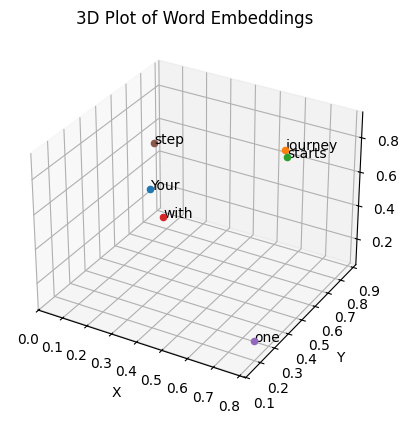

In [112]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ["Your", "journey", "starts", "with", "one", "step"]

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

print(x_coords)
print(y_coords)
print(z_coords)

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

# Set labels for axes
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.title('3D Plot of Word Embeddings')
plt.show()

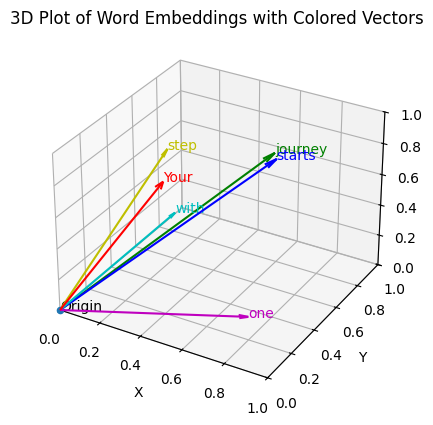

In [113]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for x, y, z, word, color in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0 , 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.scatter(0, 0, 0)
ax.text(0, 0, 0, "Origin")

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')


# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<div class="alert alert-block alert-info">
So journey and starts will be a bit more closer to each other because they are sematically more related than journey and other words.
</div>

<div class="alert alert-block alert-info">
    
Each row represents a word, and each column represents an embedding dimension
    
</div>

<div class="alert alert-block alert-info">
x(2) is the second token/element. The element/token we are looking right now is also called as "query". And x(2) is "journey" that becomes the query.
Corresponding vector z(2) is an embedding which contains information about x(2) and all other input elements x(1) to x(T).
</div>

<div class="alert alert-block alert-info">
First step of implementing self attention is to compute the intermediate values w, also referred to as attention scores.
</div>

<img src="images/attention_score.png" width="600" />

<div class="alert alert-block alert-info">
We have to basically quantify how much importance/attention should be paid to each of these other words. x(2) which is "journey" is the query. This is 
quantified by a mathematical metric called attention score. So attention score exist between the query and every input vector.

Embedding vectos encode meaning. So of two vectors are alligned to each other which means that they are parallel to each other or if their angles are closer
to each other like "journey" and "start", it implies that they have some sort of similarity in their meaning so it makes sense that more importance should be
paid to "start" vector. The vector "one" is almost perpendicular to the vector "journey" which means that they don't have similarity in meaning. So when we 
assign importance probably the vector corroesponding to "one" should have less importance than the vector corroesponding to "starts" for the query
"journery".

Dot product is the mathematical operation which would quantify this allignment. Dot product of two vectors is basically product of the magnitude of the vectors
multiplied by the cosine of the angle between them |a||b|cosθ. So if two vectors are alligned, the angle between them is 0. cos0 is 1. So dot product will be 
maximum. Whereas when two vectors are not at all alligned with each other that means they are perpendicular to each other. cos90 is 0. So there is no
similarity between these vectors and dot product is 0. 

So higher the dot product more alligned the vectors are. Lower the dot product the vectors are not alligned. So the dot product actually encodes the information
about how alligned or not alligned the vectors are.

So we can use dot product to find the attention score between my query vector and the input vector. Dot product encodes the meaning of how far apart the vectors
are.

So the intermediate attention scores are calculated between the query token and each of the input token. And the way attention scores are calculated is that we
take dot product the query token and every other input token.

So in the context of self attention mechanisms dot product determines the extent to which elements of a sequence attend to one another. Higher the dot product,
higher the similarity and attention scores between two elements.
</div>

<div class="alert alert-block alert-info">
    
The second input token serves as the query    
</div>

In [114]:
query = inputs[1] # 2nd input token is the query. python has zero based indexing system.
print("query: ", query)
print("inputs.shape: ", inputs.shape)
print("inputs.shape[0]: ", inputs.shape[0])

# attention_scores as an empty tensor
attn_scores_2 = torch.empty(inputs.shape[0])
print("attn_scores_2: ",attn_scores_2)
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

# Each of the element of the attention score is a dot product between the input vector and the query vector.
print("attn_scores_2: ", attn_scores_2)

query:  tensor([0.5500, 0.8700, 0.6600])
inputs.shape:  torch.Size([6, 3])
inputs.shape[0]:  6
attn_scores_2:  tensor([0., 0., 0., 0., 0., 0.])
attn_scores_2:  tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


<div class="alert alert-block alert-info">
The second, third and the sixth value have the largest attention scores. So second is the word "journey", third is the word "starts" and sixth is the word
"step". Of course "journey" has the high attention score because the query itself is "journey".

Fift element "one" has the lowest attention score. They "journey" vector and "one" vector are almost at 90 degrees. They are not at all aligned with each
other and that is exactly captured in the attention scores
</div>

<div class="alert alert-block alert-info">

In the next step, we normalize each of the attention scores that we computed previously. Why normalistion is needed is because we want our values to be 
interpretable and they are not right now. Because if you sum up the attention scores they are more than 1, so we can not express these in terms of percentages.
and thats why are going to normalize the attention scores.

The main goal behind normalization is to obtain attention weights that sum upto 1. The normalization is a convention that is useful for interpretation and for
maintaining  training stability in an LLM. We are going to do back propagation later so we need stability during training procedure and thats why normlization 
is integrated in many machine learning frameworks. Normalization helps when we are back propagating and including gradient descent.
</div>

<div class="alert alert-block alert-success">

The main goal behind the normalization  is to obtain attention weights
that sum up to 1. 

This normalization is a convention that is useful for interpretation and for
maintaining training stability in an LLM. 

Here's a straightforward method for achieving this
normalization step:

</div>

In [115]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


<div class="alert alert-block alert-info">
attention weights and attention scores represent the same thing. Intuitively they mean the same thing.Onlyu difference is that all attention weights 
sum up to 1 whereas thats not the case with attention scores.
</div>

<div class="alert alert-block alert-info">
    
In practice, it's more common and advisable to use the softmax function for normalization.

This approach is better at managing extreme values and offers more favorable gradient
properties during training. 

Below is a basic implementation of the softmax function for
normalizing the attention scores: 
</div>

<img src="images/summation_normalization.png" width="600" />

<div class="alert alert-block alert-info">
Why softmax is preferred as compared to normal summation especially when we consider extreme values.

When we consider extreme values like in above case 400 is extremely high , so normalization should convey this information that you should completely neglect
these other values(1, 2, 3). SO ideally we would want these normalized values to be 0 for these smaller values and we want the normalized value to be 1 for 
these extremely high value. But thats not the case with the summation operation.

With the summation operation these values will be around 0.0025 and 0.99. We might think that these is almost close to 1 but it should not be almost close to 
1 it should be exactly equal to 1. The reason that why this is problem is because when we get values like this they are not exactly equal to 0. So when we are
doing back propagation and gradient descent it confuses the optimizer and the optimizer still gives some weightage to these values although we should not give
any weightage to these values. Ideally normalization scheme should be such that when we normalize the small values should be close to zero in such as case
and the extremely large values should be close to 1 and that is not acheived through this summation based normalization. However this is acheived through a 
softmax based normalization.
</div>

<img src="images/softmax_based_normalization.png" width="600" />

<img src="images/python_softmax.png" width="600" />

<div class="alert alert-block alert-info">
sum = e^x1 + e^x2 + ---- + e^x6

e to the power 400 will be very huge almost infinity and e to power 1 or 2 or 3 will be very low. So after normalization 400 will be very close to 1 and smaller 
values will be very close to 0. So it is much better to use softmax when dealing with extreme values when we train large scale models like LLMs.

we case easily code such softmax in python but it is much more recommended to use the implementation provided by pytorch.

The difference between the pytorch implementation and naive implementation is that pytorch includes this (- max) so it subtracts all the values with the maximum
value before doing the exponential operation.

Even thougn e^(x1-max) can we written as e^x1 / e^max so e^max will cancel out from numerator and denomination. so eventually will be same as norma softmax
mathematical equation.

The reason (- max) is implemented is to avoid the numerical instablity when dealing with very large values or very small values. If you have very large value
as in the input or very small value it generally leads to numerical instablity and leads to error such as overflow errors. This is a computational problem so
theorotically we can get away with this implementation but when we implement computatation in python its much better to subtract with the maximum to prevent
overflow problem.
</div>

In [116]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


<div class="alert alert-block alert-info">
    
As the output shows, the softmax function also meets the objective and normalizes the
attention weights such that they sum to 1:
</div>

<div class="alert alert-block alert-warning">

In addition, the softmax function ensures that the attention weights are always positive.
This makes the output interpretable as probabilities or relative importance, where higher
weights indicate greater importance.
    
</div>

<div class="alert alert-block alert-warning">

Note that this naive softmax implementation (softmax_naive) may encounter numerical
instability problems, such as overflow and underflow, when dealing with large or small input
values. 

Therefore, in practice, it's advisable to use the PyTorch implementation of softmax,
which has been extensively optimized for performance:
    
</div>

In [117]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights: ", attn_weights_2)
print("Sum: ", attn_weights_2.sum())

Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)


<div class="alert alert-block alert-info">
    
In this case, we can see that it yields the same results as our previous softmax_naive
function:
</div>

<img src="images/context_vector_example.png" width="600" />

<div class="alert alert-block alert-info">
We have to multiple each of the input embedding vectors with the corroesponding attention weight and we will get these 6 vectors. We Sum up all these
these 6 vectors and that describes the context vector.

And we will get context vector of for example "journey".

Context vector has contributions from all other vectors so it is an enriched embedding vector. It has 25% contribution from the embedding vector but it has
all the other contributions from other vectors. And those contributions symbolize how much importance is given to other vectors.
</div>

<div class="alert alert-block alert-success">

The context vector z(2)is calculated as a weighted sum of all input
vectors. 

This involves multiplying each input vector by its corresponding attention weight:

</div>

In [118]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your     (x^1)
     [0.55, 0.87, 0.66], # journey  (x^2)
     [0.57, 0.85, 0.64], # starts   (x^3)
     [0.22, 0.58, 0.33], # with     (x^4)
     [0.77, 0.25, 0.10], # one      (x^5)
     [0.05, 0.80, 0.55]] # step     (x^6)
)

In [119]:
query = inputs[1] # 2nd input token is the query
print("query: ", query)

context_vec_2 = torch.zeros(query.shape)
print("context_vec_2: ", context_vec_2)

print("attn_weights_2: ", attn_weights_2)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print("context_vec_2: ", context_vec_2)

query:  tensor([0.5500, 0.8700, 0.6600])
context_vec_2:  tensor([0., 0., 0.])
attn_weights_2:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
context_vec_2:  tensor([0.4419, 0.6515, 0.5683])


<div class="alert alert-block alert-success">
calculations performed above

0.1385 * [0.43, 0.15, 0.89]
= [0.0596, 0.0208, 0.1233]

0.2379 * [0.55, 0.87, 0.66]
= [0.1308, 0.2070, 0.1570]

0.2333 * [0.57, 0.85, 0.64]
= [0.1320, 0.1983, 0.1493]

0.1240 * [0.22, 0.58, 0.33]
= [0.0273, 0.0719, 0.0409]

0.1082 * [0.77, 0.25, 0.10]
= [0.0833, 0.0270, 0.0108]

0.1581 * [0.05, 0.80, 0.55]
= [0.0079, 0.1265, 0.0860]
</div>

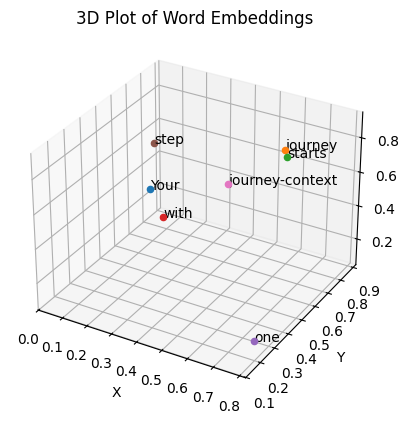

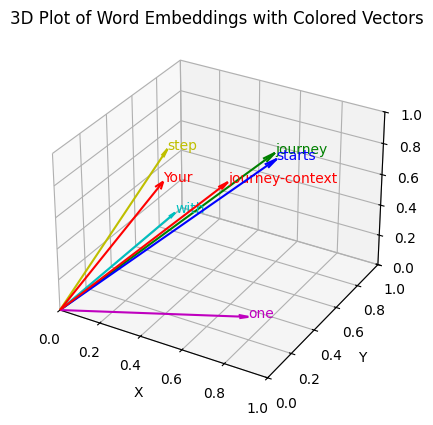

In [120]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

<div class="alert alert-block alert-info">
After computing the normalized attention weights, we calculate the context vector z(2) by multiplying the embedded input tokens x(i) with the corroesponding
attention weights and then by summing the resultant vectors
</div>

<img src="images/context_vector_calculation.png" width="600" />

<div class="alert alert-block alert-success">

Now, we can extend this computation to
calculate attention weights and context vectors for all inputs.

</div>

<div class="alert alert-block alert-success">

First, we add an additional for-loop to compute the
dot products for all pairs of inputs.

</div>

In [121]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your     (x^1)
     [0.55, 0.87, 0.66], # journey  (x^2)
     [0.57, 0.85, 0.64], # starts   (x^3)
     [0.22, 0.58, 0.33], # with     (x^4)
     [0.77, 0.25, 0.10], # one      (x^5)
     [0.05, 0.80, 0.55]] # step     (x^6)
)

attn_scores = torch.empty(6, 6)
print(attn_scores)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


<div class="alert alert-block alert-info">
    
Each element in the preceding tensor represents an attention score between each pair of
inputs.
</div>

<div class="alert alert-block alert-info">
    
When computing the preceding attention score tensor, we used for-loops in Python.
                                                            
However, for-loops are generally slow, and we can achieve the same results using matrix
multiplication:
</div>

In [122]:
attn_scores = inputs @ inputs.T

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


<div class="alert alert-block alert-success">

We now normalize each row so that the values in
each row sum to 1:

</div>

In [123]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


<div class="alert alert-block alert-warning">

In the context of using PyTorch, the dim parameter in functions like torch.softmax specifies
the dimension of the input tensor along which the function will be computed. 

By setting
dim=-1, we are instructing the softmax function to apply the normalization along the last
dimension of the attn_scores tensor. 

If attn_scores is a 2D tensor (for example, with a
shape of [rows, columns]), dim=-1 will normalize across the columns so that the values in
each row (summing over the column dimension) sum up to 1.
    
</div>

<div class="alert alert-block alert-success">

Let's briefly verify that
the rows indeed all sum to 1:

</div>

In [124]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


<div class="alert alert-block alert-success">

In the third and last step, we now use these attention weights to compute all context
vectors via matrix multiplication:

</div>

In [125]:
all_context_vecs = attn_weights @ inputs

print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


<div class="alert alert-block alert-success">

We can double-check that the code is correct by comparing the 2nd row with the context
vector z(2) calculated previously

</div>

In [126]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


<div class="alert alert-block alert-info">
    
Based on the result, we can see that the previously calculated context_vec_2 matches the
second row in the previous tensor exactly
</div>

<div class="alert alert-block alert-warning">

This concludes the code walkthrough of a simple self-attention mechanism.
    
</div>

<div class="alert alert-block alert-info">
Now we might think that we already found the context vector like above then whats the need for trainable weights, we just take the dot product and find these
context vectors. Currently we are giving more importance to "starts" because alignment between "starts" and "journey" is maximum. SO the only reason we are 
giving more importance to "starts" because it semantically matches with "journey".

But two vectors might not be semantically alligned but may be they are more important in the context of the current sentence. For example, "journey" and "one" 
are not semantically alligned but may be in the context of current sentence "one" is the vector which is more important.

So apart from the meaning you also need to capture the information of the context like what is happening in the current sentence and without trainable weights
we won't be able to capture the context effectively. Right noe we did manage to capture the context somewhat but we only gave attention to words which are similar
meaning to the query. But even if a word is not similar in meaning it still might deserve attention in the context of the current sentence.   
</div>

<img src="images/why_trainable_weights_1.png" width="600" />

<img src="images/why_trainable_weights_2.png" width="600" />

<div class="alert alert-block alert-info">
Without trainable weights mat and warm might be vectors like perpendicular vectors and they might not be related because their meaning is not related.
That does not mean we should not pay attention to mat because in this context probably mat is the most important if the query is warm because the mat is warm.
But the meaning of mat and warm is not related. Thats why we need trainable weights. With trainable weights the model can learn that model should pay more
attention to mat, even though mat is not semantically similar to warm in traditional embedding space.

The trainable weights allows the model to learn that warm often follows mat in the context like this one and thats how it captures long range dependencies. 
</div>


## IMPLEMENTING SELF ATTENTION WITH TRAINABLE WEIGHTS

<div class="alert alert-block alert-info">
Self attention mechanism used in original transformer architecture, the GPT models and most other popular LLMs. This self attention mechanism is also called
as "scaled-dot-product attention"
</div>

<div class="alert alert-block alert-info">
We will introduce weight matrices that are updated during model training. These trainable weight matrices are crucial so that the model can learn
to produce "good context vectors"
</div>

<div class="alert alert-block alert-info">
At the heart of this trainable weight machines are three terminolgies query, key and value.

We will implement the self attention mechanisms step by step by introducing 3 trainable weight matrices: W(q) , w(k) and w(v). First is called weight matrix for
query, second is called weight matrix for key and third is called weight matrix for value.
</div>

<img src="images/query_key_value_example_matrices.png" width="600" />

<div class="alert alert-block alert-info">
First step is converting input embedding which are input vectors into key, query and value vectors. The goal as earlier is the same is to get from input
embeddings to context embeddings for every token.

So input we have 3-D vector representation for each word.

To construct query, key and value matrix 3 trainable weight matrices are needed. First trainable weight matrix is called as query weight matrix, second trainable weight 
matrix is called as key weight matrix and the third trianable weight matrix is called as value weight matrix.

Input has dimension 6*3, one for each input token and 3 columns as 3 dimensional. All three trainable weight matrices are initalized with random values, buy these
are trained. We don't know these parameters so we initialize them randomly and then train them. So to get context vector these are the ones which are optimized.

These matrices project the inputs to a different dimension space. Query matrix dimension is 3*2. Multiplying query weight matrix with input matrix, we get
resultant matrix which is called as the queries and it is a 6*2 matrix. Each row here still corresponds to the individual words.

The simplest way to think of the query matrix and all the other  matrices is the transformation from  3-D space to a 2-D space in this case.

Similarly we get the key matrix and value matrix.

Every row in the query, key and value matrices represent one token and representation of that token. So after getting these 3 matrices we are not going to look
at the input embeddings again. The input matrix has been transformed into three marices.
</div>

In [127]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

<div class="alert alert-block alert-success">

Let's begin by defining a few variables:

</div>

<div class="alert alert-block alert-info">
    
#A The second input element

#B The input embedding size, d=3


#C The output embedding size, d_out=2

</div>

In [128]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #C

<div class="alert alert-block alert-info">
    
Note that in GPT-like models, the input and output dimensions are usually the same. 

But for illustration purposes, to better follow the computation, we choose different input (d_in=3)
and output (d_out=2) dimensions here.

</div>

<div class="alert alert-block alert-success">

Next, we initialize the three weight matrices Wq, Wk and Wv

</div>

In [129]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
W_key = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
W_value = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)

print("W_query: ", W_query)
print("W_key: ", W_key)
print("W_value: ", W_value)

W_query:  Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
W_key:  Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
W_value:  Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


<div class="alert alert-block alert-info">
    
Note that we are setting requires_grad=False to reduce clutter in the outputs for
illustration purposes. 

Later we going to train the values in the matrices through back propagation so at that time we need to compute gradients and at that time we will set the
requires_grad = True.

If we were to use the weight matrices for model training, we
would set requires_grad=True to update these matrices during model training.

</div>

<div class="alert alert-block alert-success">

Next, we compute the query, key, and value vectors as shown earlier
</div>

In [130]:
print("x_2: ", x_2)
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print("query_2: ",query_2)
print("key_2: ",key_2)
print("value_2: ",value_2)

x_2:  tensor([0.5500, 0.8700, 0.6600])
query_2:  tensor([0.4306, 1.4551])
key_2:  tensor([0.4433, 1.1419])
value_2:  tensor([0.3951, 1.0037])


<div class="alert alert-block alert-info">
    
As we can see based on the output for the query, this results in a 2-dimensional vector. 

This is because: we set the number of columns of the corresponding weight matrix, via d_out, to 2:

</div>

<div class="alert alert-block alert-success">

Even though our temporary goal is to only compute the one context vector z(2),  we still
require the key and value vectors for all input elements. 

This is because they are involved in computing the attention weights with respect to the query q(2)
</div>

<div class="alert alert-block alert-success">

We can obtain all keys and values via matrix multiplication:
</div>

In [131]:
keys = inputs @ W_key
values = inputs @ W_value
queries = inputs @ W_query

print("keys.shape: ", keys.shape)
print("values.shape: ", values.shape)
print("queries.shape: ", queries.shape)

print("keys: ", keys)
print("values: ", values)
print("queries: ", queries)

keys.shape:  torch.Size([6, 2])
values.shape:  torch.Size([6, 2])
queries.shape:  torch.Size([6, 2])
keys:  tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])
values:  tensor([[0.1855, 0.8812],
        [0.3951, 1.0037],
        [0.3879, 0.9831],
        [0.2393, 0.5493],
        [0.1492, 0.3346],
        [0.3221, 0.7863]])
queries:  tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])


<div class="alert alert-block alert-info">
    
As we can tell from the outputs, we successfully projected the 6 input tokens from a 3D
onto a 2D embedding space:

</div>

<img src="images/attention_score_query_key_example.png" width="600" />

<div class="alert alert-block alert-info">
Attention score: if we are given a query how does the other keys attend to that query.

Lets say we have a query for the second word "journey" and the query is 2-D vector. Now we have to find out how does this query attend to the keys for the 
different input words. So you can think of the keys right now as just individual tokens like we did earlier. Earlier the query was just that particular token,
we did not have separate vector for query. Earlier "journey" token was itself the query. For intution we can think query as the token itself, although its a bit different.

Now we are trying to find how the q(2) which is query for "journey" token and how the other words attend to "journey". Which means that when i am predicting the
next word how much importance should i give to "journey", how much to "step" etc.

So my query is "journey" and I am going to look at how much importance i need to give to the other words. So thats why we need to find the attention scores between 
query and  the key.

Currently we are finding the attention score between the query and the key. Earlier we just found the attention score between the input embedding vector and the
other embedding vectors by taking the dot product. But now we don't have input embedding space we are in an abstract space, We are in query, key and value abstract phase.

We are going to find out how query number 2 attends to the different key vectors. We are going to use dot vector here also. We are going to find attention scores
between a particular query and all the other keys. Every query will have an attention scores with all the other keys.
</div>

<img src="images/attention_score_example_2.png" width="600" />

<div class="alert alert-block alert-success">
Attention scores contain the information that when you look at the query for journey how much importance should be given to other words.
</div>

<div class="alert alert-block alert-success">

First, let's compute the attention score ω22</div>

In [132]:
keys_2 = keys[1] #A
print("keys_2: ", keys_2)
print("query_2: ", query_2)
attn_score_22 = query_2.dot(key_2)
print("attn_score_22: ",attn_score_22)

keys_2:  tensor([0.4433, 1.1419])
query_2:  tensor([0.4306, 1.4551])
attn_score_22:  tensor(1.8524)


<div class="alert alert-block alert-success">
Again, we can generalize this computation to all attention scores via matrix multiplication:</div>

In [133]:
attn_scores_2 = query_2 @ keys.T # All attention scores for given query. Transpose is done for multiplication
print("attn_scores_2: ", attn_scores_2)

attn_scores_2:  tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [134]:
attn_scores = queries @ keys.T  # omega
print("attn_scores: ", attn_scores)

attn_scores:  tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


<div class="alert alert-block alert-info">
First row contains the attention scores between the first query and all the other keys. The second row contains the attention scores between second query and
all the other keys. Similarly last row contains the attention score between the last query and all the other keys. 
</div>

<div class="alert alert-block alert-info">
So first step was to convert to the input embedding vectors to key, query and value matrices. Second step was to use key and query matrices to get to the
attention scores.

Attention scores are not interpretable here so we need to normalize the attn_scores. Also the second advantage of normalization is that it helps when we do
back propagation. Generally in many machine learning frameworks its better to normalize things so that scale stays consistent between 0 and 1. 

So now we normalize attn_scores to get attention weights.
</div>

<div class="alert alert-block alert-success">
    
We compute the attention weights by scaling the attention scores and using the softmax function we used earlier. 

The difference to earlier is that we now scale the attention scores by dividing them by the square root of the embedding dimension of the keys thats 
why this is called as scaled Dot Product attention.

Note that taking the square root is mathematically the same as exponentiating by 0.5:</div>

In [135]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print("attn_weights_2: ", attn_weights_2)
print("d_k: ", d_k)

attn_weights_2:  tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
d_k:  2


<div class="alert alert-block alert-info">
This second row belongs to the word "journey" so we can say that when query is "journey" pay 15% attention to "your", 22% to "journey" itself etc.
</div>

## WHY DIVIDE BY SQRT (DIMENSION)

<div class="alert alert-block alert-warning">

Reason 1: For stability in learning

The softmax function is sensitive to the magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced. This causes the softmax output to become "peaky," where the highest value receives almost all the probability mass, and the rest receive very little.

In attention mechanisms, particularly in transformers, if the dot products between query and key vectors become too large (like multiplying by 8 in this example), the attention scores can become very large. This results in a very sharp softmax distribution, making the model overly confident in one particular "key." Such sharp distributions can make learning unstable,
    
</div>

In [136]:
import torch

# Define the tensor
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

# Apply softmax without scaling
softmax_result = torch.softmax(tensor, dim=-1)
print("Softmax without scaling:", softmax_result)

# Multiply the tensor by 8 and then apply softmax
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)
print("Softmax after scaling (tensor * 8):", softmax_scaled_result)


Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


## BUT WHY SQRT?

<div class="alert alert-block alert-warning">

Reason 2: To make the variance of the dot product stable

The dot product of  Q and K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows with the dimension. 

Dividing by sqrt (dimension) keeps the variance close to 1

If variance increases a lot it makes the learning very unstable. If variance is not close then learnings will fly off in random directions and the generally
variance should stay to 1. That helps in back propagation. 

If we don't scale then as the dimensions of the query and key increase the dot product variance can become huge. And we don't want that. 
    
</div>

In [137]:
import numpy as np

# Function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)

        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)

    # Calculate variance of the dot products
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling
        

# For dimension 5
variance_before_5, variance_after_5 = compute_variance(5)
print(f"Variance before scaling (dim=5): {variance_before_5}")
print(f"Variance after scaling (dim=5): {variance_after_5}")

# For dimension 20
variance_before_100, variance_after_100 = compute_variance(100)
print(f"Variance before scaling (dim=100): {variance_before_100}")
print(f"Variance after scaling (dim=100): {variance_after_100}")
        

Variance before scaling (dim=5): 5.009897459165111
Variance after scaling (dim=5): 1.0019794918330223
Variance before scaling (dim=100): 101.23229590640604
Variance after scaling (dim=100): 1.0123229590640603


<img src="images/attention_weights_diagram.png" width="600" />

<div class="alert alert-block alert-success">
    
We now compute the context vector as a weighted sum over the value
vectors. 

Here, the attention weights serve as a weighting factor that weighs the respective
importance of each value vector. 

We can use matrix multiplication to
obtain the output in one step:</div>

<img src="images/context_vector_diagram.png" width="600" />

<div class="alert alert-block alert-info">
The last step is multiplying each value vector with its respective attention weights and then summing them to obtain the context vector.

Its very similar to what we did earlier we did not have this value vector. We just had the input embedding vector but the whole assence here is that we
have calculated the attention weights so now its time to assign the corroesponding weightage to each value vector or embedding vector and sum them up to give
the context vector.
</div>

<img src="images/attention_weight_and_values.png" width="600" />

In [138]:
<div>
Attention weights for the journey is the second row. Meaning we are paying 15% attention to "your", 22% attention to "journey", 22% attention to "beigns" etc.

We have to encode all this information to find the context vector. Its simple take "your" vector multiply by 15%, "journey" vector by 22% and so on. Then by 
adding all these we get context vector for "journey".
</div>

SyntaxError: invalid syntax (2535028056.py, line 1)

<img src="images/context_vector_for_journey.png" width="600" />

<div class="alert alert-block alert-info">
context vector is richer than input embedding vector. Input embedding vector for "journey" has no infomation about how much attention to be paid to other
input vectors. So context vector is enriched vector. It contains semantic meaning of "journey" plus it also contains how all other words attend to "journey".

6x6 attention matrix multiplied by 6x2 value vector will result in 6x2 context vector matrix. Each row corroesponds to a context vector for that token.
</div>

In [139]:
context_vec_2 = attn_weights_2 @ values
print("context_vec_2: ", context_vec_2)

context_vec_2:  tensor([0.3061, 0.8210])


<div class="alert alert-block alert-success">
    
So far, we only computed a single context vector, z(2). 

In the next section, we will generalize the code to compute all context vectors in the input sequence, z(1)to z (T)</div>

## IMPLEMENTING A COMPACT SELF ATTENTION PYTHON CLASS

In [140]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

    # The input dimension is the input embedding vector dimension
    # Output dimension is what we want keys, values and queries dimension.
    # In GPT and other LLMs these two are generally similar.
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value

        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec
        

<div class="alert alert-block alert-warning">

In this PyTorch code, SelfAttention_v1 is a class derived from nn.Module, which is a
fundamental building block of PyTorch models, which provides necessary functionalities for
model layer creation and management.    
</div>

<div class="alert alert-block alert-warning">

The __init__ method initializes trainable weight matrices (W_query, W_key, and
W_value) for queries, keys, and values, each transforming the input dimension d_in to an
output dimension d_out.

</div>

<div class="alert alert-block alert-warning">

During the forward pass, using the forward method, we compute the attention scores
(attn_scores) by multiplying queries and keys, normalizing these scores using softmax.

</div>

<div class="alert alert-block alert-success">
    
Finally, we create a context vector by weighting the values with these normalized attention
scores.
    
</div>

In [141]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


<div class="alert alert-block alert-info">

Since inputs contains six embedding vectors, we get a matrix storing the six
context vectors, as shown in the above result. 
</div>

<div class="alert alert-block alert-info">

As a quick check, notice how the second row ([0.3061, 0.8210]) matches the contents of
context_vec_2 in the previous section.
    
</div>

<div class="alert alert-block alert-warning">

We can improve the SelfAttention_v1 implementation further by utilizing PyTorch's
nn.Linear layers, which effectively perform matrix multiplication when the bias units are
disabled. 

</div>

<div class="alert alert-block alert-warning">

Additionally, a significant advantage of using nn.Linear instead of manually
implementing nn.Parameter(torch.rand(...)) is that nn.Linear has an optimized weight
initialization scheme, contributing to more stable and effective model training.

</div>

In [142]:
class SelfAttention_v2(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec
        

In [143]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


<div class="alert alert-block alert-info">

Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because they
use different initial weights for the weight matrices since nn.Linear uses a more
sophisticated weight initialization scheme.
    
</div>

<img src="images/query_key_value_meaning.png" width="600" />

## HIDING FUTURE WORDS WITH CAUSAL ATTENTION

<div class="alert alert-block alert-info">
Causal attention also called as masked attention is a special form of self attention.

It restricts the model to only consider previous and current inputs in a given sequence, when processing any given token.

This is in contrast to the self attention mechanism which allows access to the entire input sequence at once.

Earlier during attention score matrix when we look at a particular query like "journey" we look at its attention with all the other tokens "your", "begins", 
"one", "step" etc. We don't look at whether these tokens came before "journey" or after "journey". This is what changed in causal attention.

In Causal attention when we look at any particular query we only consider the attention of that query with respect to tokens which come before that query.
</div>

<div class="alert alert-block alert-info">
When computing attention scores, the causal attention mechanism ensures that the model only factors in tokens that occur at or before the current token in the
sequence.

To achieve this in GPT like LLMs, for each token processed, we mask out the future tokens, which come after the current token in the input text.

Until now the attention weight matrix which we have seen looks something like on the left hand in the below image. So if we look at the row for journey you can
get the attention weight of the "journey" with all the other tokens. So this row consists of 6 values. 

But the main goal of the causal attention mechanism is that when you look at a particular token such as "journey" you should only consider the attention score of
"journey" with the words which come before "journey" such as "your" and "journey". So there are only two attention scores which are relevant here. All the 
attention scores which come after this are masked out which means they no longer exist they are set to zero. Similarily when we look at "with", so before
"with" you have "your journey starts with", there are 4 tokens, so we have the attention scores for those 4 tokens, but the attention scores for all the future 
tokens are masked out or will be set to 0. 

When we look at masking, the context size is also important because the context size specifies how many words the LLM can look at before predicting the next word.

We mask out the attention weights above diagonal and then we normalize the non masked attention weights such that the attention weights sum upto 1 in each row. 
So normalization is done once more so that whatever attention weights are remaining they indeed sum upto 1.

So the masked weight basically above the diagonal is called as the causal attention mask because we are masking out all of those attention weights.
</div>

<img src="images/causal_attention_masked_out.png" width="600" />

<div class="alert alert-block alert-info">
To apply a causal attention mask, we will get the attention weights in a similar manner to what we have obtained and then we will just the elements above the 
diagonal to be 0 and then we re normalize the attention weights.
</div>

<img src="images/causal_attention_process.png" width="600" />

<div class="alert alert-block alert-success">

Let's work with the attention scores and weights from the previous section to code the causal attention mechanism.
    
</div>

<div class="alert alert-block alert-success">

As illustrated we compute the attention weights using the
softmax function as we have done in previous sections:    
</div>


<div class="alert alert-block alert-info">

Reuse the query and key weight matrices of the SelfAttention_v2 object from the previous section for
convenience
    
</div>

In [144]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [145]:
queries = sa_v2.W_query(inputs) #A
keys = sa_v2.W_key(inputs)
print("queries: ", queries)
print("keys: ", keys)
attn_scores = queries @ keys.T
print("attn_scores: ", attn_scores)
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print("attn_weights: ", attn_weights)
print(attn_weights)

queries:  tensor([[ 0.6600, -0.2047],
        [ 0.9091, -0.4471],
        [ 0.8960, -0.4419],
        [ 0.5034, -0.2633],
        [ 0.4088, -0.2232],
        [ 0.6628, -0.3292]], grad_fn=<MmBackward0>)
keys:  tensor([[ 0.3147, -0.4016],
        [-0.0298, -0.4459],
        [-0.0170, -0.4262],
        [-0.1054, -0.2724],
        [ 0.2185,  0.0482],
        [-0.2258, -0.4782]], grad_fn=<MmBackward0>)
attn_scores:  tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)
attn_weights:  tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498

<div class="alert alert-block alert-success">

We can now use PyTorch's tril function to create a mask
where the values above the diagonal are zero:

</div>

In [147]:
context_length = 6

In [148]:
torch.ones(context_length, context_length)

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [149]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


<div class="alert alert-block alert-success">

Now, we can multiply this mask with the attention weights to zero out the values above the
diagonal:

</div>

In [150]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


<div class="alert alert-block alert-info">

As we can see, the elements above the diagonal are successfully zeroed out
    
</div>

<div class="alert alert-block alert-success">

The third step is to renormalize the attention weights to sum up to 1 again in
each row. 

We can achieve this by dividing each element in each row by the sum in each
row:

</div>

In [153]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
print(row_sums)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[0.1921],
        [0.3700],
        [0.5357],
        [0.6775],
        [0.8415],
        [1.0000]], grad_fn=<SumBackward1>)
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


<div class="alert alert-block alert-info">

The result is an attention weight matrix where the attention weights above the diagonal are
zeroed out and where the rows sum to 1.

</div>

<div class="alert alert-block alert-success">

While we could be technically done with implementing causal attention at this point, we can
take advantage of a mathematical property of the softmax function. 

We can implement the computation of the masked attention weights more efficiently in fewer steps.

</div>

<div class="alert alert-block alert-info">
The main purpose of causal attention essentially is to not have any influence of the future tokens. But if you see earlier we applied softmax to the attention
scores. So in the attention weight matrix even if you look at the first two entries of the second row , these two entries are already influenced by all the 
other entries because when you take the softmax, in the denominator you have the exponential sum o f the weights. So even if you zero out all the future tokens
its not essentially cancelling the influence of the future tokens because the future tokens have already influenced the initial two values when we take the 
softmax that is what disadvantage of this approach we are employing softmax that is what disadvantage of this. We are applying softmax earlier and then again
we are doing normalization by dividing with the sum.

So this leads to data leakage problem, although we zero out the elements above the diagonal, since we are taking the softmax before, the elements which come in 
the future do affect the previous elements also.
</div>

<div class="alert alert-block alert-info">
Lets say we have the attention score matrix so instead of applying softmax earlier and getting the attention weight matrix we replace values above diagonals
with -inifinity and then we take the softmax. When we take the exponential of -infinity it is going to be zero. What this ensures that we are not having a
data leakage, there is not influence of future tokens now. 
</div>

<img src="images/causal_attention_issue.png" width="600" />

<img src="images/causal_attention_efficient_way.png" width="600" />

<div class="alert alert-block alert-success">

The softmax function converts its inputs into a probability distribution. 

When negative
infinity values (-∞) are present in a row, the softmax function treats them as zero
probability. 

(Mathematically, this is because e
-∞ approaches 0.)


We can implement this more efficient masking "trick" by creating a mask with 1's above
the diagonal and then replacing these 1's with negative infinity (-inf) values:

</div>

In [154]:
print(attn_scores)

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [155]:
torch.triu(torch.ones(context_length, context_length))

tensor([[1., 1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.]])

In [171]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print(mask)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


In [172]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


<div class="alert alert-block alert-success">

Now, all we need to do is apply the softmax function to these masked results, and we are
done.

</div>

In [170]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


<div class="alert alert-block alert-info">

As we can see based on the output, the values in each row sum to 1, and no further
normalization is necessary.

</div>

<div class="alert alert-block alert-warning">

Masking in Transformers sets scores for future tokens to a large negative value, making their influence in the softmax calculation effectively zero. 

The softmax function then recalculates attention weights only among the unmasked tokens. 

This process ensures no information leakage from masked tokens, focusing the model solely on the intended data.

</div>

<div class="alert alert-block alert-warning">

We could now use the modified attention weights to compute the context vectors via
context_vec = attn_weights @ values.

However, in the next section,
we first cover another minor tweak to the causal attention mechanism that is useful for
reducing overfitting when training LLMs.

</div>

### MASKING ADDITIONAL ATTENTION WEIGHTS WITH DROPOUT

<div class="alert alert-block alert-info">
Dropout is a deep learning technique where randomly selected hidden layer units are ignored during training. Here we take a neural network and you randomly
switch on neurons in different layers to 0. Usually when you are training some neurons become lazy and they don't do any work because they realize that other
neurons anyway doing most of the work and the result is pretty well so they will just switch off so thats a lazy neuron problem or co-dependency problem. 

What dropout ensures is that when a lazy neuron sees that other neuron is switched off it is forced to do the work. So dropout randomly turns neurons off so
it ensures that all the neurons essentially participates and this leads to better generalization, it prevents overfitting and it does better on the test data. 

So the main advantage of Dropout is that it prevents overfitting and improves generalization performance.

In transformer architecture including models like GPT, dropout  in attention mechanism is implemented and usually applied in two specific areas :
1-> after calculation of the attention scores, 2-> After applying attention weight to the value vectors.

More common way is to implement dropout after calculation of the attention weights or the attention scores.
</div>

<div class="alert alert-block alert-info">
Essentially what is done in the the dropout is that lets suppose you have an attention weight matrix with causal attention implemented so all future tokens have
been masked. We will first create a dropout mask. What this dropout mask signifies is what all neurons need to be randomly turned off so lets say we implement
a dropout with a probability of 0.5, this means that on average 50% of the attention weights in each row will be turned on.

Wherever the mask appears those particular elements need to be zeroed out. So if you look at the 4th row 1st, 4th and 5th have the mask so we have only two 
surviving entries 0.24 and 0.24.

So essentially what dropout does in very simple terms is that it looks at rows and then it randomly swiches off attention weights with a given particular 
probability.
</div>

<img src="images/dropout.png" width="600" />

<div class="alert alert-block alert-success">

In the following code example, we use a dropout rate of 50%, which means masking out
half of the attention weights.

When we train the GPT model in later chapters, we will use a
lower dropout rate, such as 0.1 or 0.2.
</div>

<div class="alert alert-block alert-success">

In the following code, we apply PyTorch's dropout implementation first to a 6×6 tensor
consisting of ones for illustration purposes:
</div>

In [173]:
example = torch.ones(6, 6)#B
print(example)

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])


In [175]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) #A
print("dropout: ", dropout)
example = torch.ones(6, 6)  #B
print("example: ", example)
print("dropout(example): ", dropout(example))
# As dropout will switch off 50% of the weights and since 50% of the weights are swtiched off, all the other weights are rescaled by that amount. So all 
# other weights which are not switched off are rescaled by two. This is probablistic so if we take 10000 rows, you will see that on an average 50% of every
# row will be swiched off. But that does not guarantee that 3 exact neurons or weights will be switched off in every row. 2,3, or 4 neurons will be switched
# off, but on an average 3 neurons will be switched off in every row.

dropout:  Dropout(p=0.5, inplace=False)
example:  tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
dropout(example):  tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


<div class="alert alert-block alert-info">

When applying dropout to an attention weight matrix with a rate of 50%, half of the
elements in the matrix are randomly set to zero. 

To compensate for the reduction in active
elements, the values of the remaining elements in the matrix are scaled up by a factor of
1/0.5 =2. 

This scaling is crucial to maintain the overall balance of the attention weights,
ensuring that the average influence of the attention mechanism remains consistent during
both the training and inference phases.
</div>

<div class="alert alert-block alert-success">

Now, let's apply dropout to the attention weight matrix itself:

</div>

In [176]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


<div class="alert alert-block alert-info">

As we can see above, the resulting attention weight matrix now has additional elements zeroed out and the
remaining ones rescaled.
    
</div>

<div class="alert alert-block alert-warning">

Having gained an understanding of causal attention and dropout masking, we will
develop a concise Python class in the following section. 

This class is designed to facilitate
the efficient application of these two techniques.

</div>

### IMPLEMENTING A COMPACT CAUSAL ATTENTION CLASS

<div class="alert alert-block alert-success">

We will now incorporate the causal attention and dropout modifications into
the SelfAttention Python class. 

This class will then serve as a
template for developing multi-head attention in the upcoming section.

</div>

<div class="alert alert-block alert-success">

Before we begin, one more thing is to ensure that the code can handle batches
consisting of more than one input. 

This will ensure that the CausalAttention class supports the batch
outputs produced by the data loader we implemented earlier.

</div>

<div class="alert alert-block alert-success">

For simplicity, to simulate such batch inputs, we duplicate the input text example:

</div>

<div class="alert alert-block alert-info">

 2 inputs with 6 tokens each, and each token has embedding dimension 3
    
</div>

In [178]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


<div class="alert alert-block alert-info">

This results in a 3D tensor consisting of 2 input texts with 6 tokens each, where each token
is a 3-dimensional embedding vector.
    
</div>

<div class="alert alert-block alert-success">

The following CausalAttention class is similar to the SelfAttention class we
implemented earlier, except that we now added the dropout and causal mask components
as highlighted in the following code.
    
</div>

<div class="alert alert-block alert-info">

Step 1: Compared to the previous SelfAttention_v1 class, we added a dropout layer.
    
Step 2: The register_buffer call is also a new addition (more information is provided in the following text).

Step 3:  We transpose dimensions 1 and 2, keeping the batch dimension at the first position (0).

Step 4: In PyTorch, operations with a trailing underscore are performed in-place, avoiding unnecessary memory
copies
    
</div>

In [186]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length,
                 dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1)) # New

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) # Why 1,2 because we are only interested in the num_tokens and d_in dimension. Remember we are looking at 
        #batches. When we look at the first batch we only care about number of tokens and the input dimensions, same for all the batches.
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)  # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights) # New

        context_vec = attn_weights @ values
        return context_vec

<img src="images/queries_batch.png" width="600" />
<img src="images/keys_batch.png" width="600" />
<img src="images/keys_transpose_batch.png" width="600" />
<img src="images/attn_scores_batch.png" width="600" />

<div class="alert alert-block alert-warning">

The use of register_buffer in
PyTorch is not strictly necessary for all use cases but offers several advantages here. 

For
instance, when we use the CausalAttention class in our LLM, buffers are automatically
moved to the appropriate device (CPU or GPU) along with our model, which will be relevant
when training the LLM in future chapters. 

This means we don't need to manually ensure
these tensors are on the same device as your model parameters, avoiding device mismatch
errors.

</div>

<div class="alert alert-block alert-success">

We can use the CausalAttention class as follows, similar to SelfAttention previously:
    
</div>

In [187]:
d_in = 3
d_out = 2

In [188]:
print(d_in)

3


In [189]:
print(d_out)

2


In [191]:
torch.manual_seed(123)
context_length = batch.shape[1]
print("context_length: ", context_length)
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_length:  6
context_vecs.shape: torch.Size([2, 6, 2])


In [192]:
print(context_vecs)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


<div class="alert alert-block alert-info">

As we can see, the resulting context vector is a 3D tensor where each token is now represented by a 2D
embedding:
    
</div>

<div class="alert alert-block alert-warning">

In the next section, we will expand on this concept
and implement a multi-head attention module, that implements several of such causal
attention mechanisms in parallel.

</div>